# Statistiques descriptives - Base GDELT GKG (2015 → aujourd'hui)

Ce notebook explore la base Parquet hebdomadaire produite par `gdelt_weekly_pipeline.py`.

**Rappel du schéma de chaque fichier `gdelt_YYYY-MM.parquet` :**

| Colonne | Description |
|---|---|
| `GKGRECORDID` | identifiant unique de l'enregistrement GKG |
| `DATE` | horodatage GDELT au format `YYYYMMDDHHMMSS` |
| `SourceCollectionIdentifier` | canal de collecte GDELT (1=WEB, 2=CITATIONONLY - d'après la documentation GDELT) |
| `DocumentIdentifier` | URL de l'article source |
| `SourceCommonName_ID` | identifiant entier du média, à mapper via `gdelt_sources_mapping.json` |
| `EnhancedThemes` | thèmes GKG (format `THEME,offset;THEME,offset;...`) |
| `EnhancedLocations` | lieux géolocalisés détectés |
| `Persons` | personnes citées (séparées par `;`) |
| `Organizations` | organisations citées (séparées par `;`) |
| `Tone` | tonalité moyenne de l'article (échelle GDELT, -100 à +100) |
| `WordCount` | nombre de mots approximatif de l'article |
| `IsTranslingual` | 1 si l'article provient de la master list translingue, 0 sinon |
| `TranslationInfo` | infos de traduction (si article non anglophone) |


**DuckDB** : interroger directement les fichiers Parquet sans tout charger en RAM 
    
**pandas/matplotlib/seaborn** : agrégations plus fines et visualisations


## 1. Installation, imports and loadings

In [1]:
import os
import gc

os.environ["OMP_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["NUMEXPR_NUM_THREADS"] = "2"

In [2]:
import glob
import json
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import matplotlib.dates as mdates
import plotly.express as px
                                
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
                               
DATA_DIR = Path("/data/gdelt/gdelt_parquet_db")
SOURCE_MAP_PATH = Path("/data/gdelt/gdelt_sources_mapping.json")

parquet_files = sorted(glob.glob(str(DATA_DIR / "gdelt_*.parquet")))
print(f"✔ {len(parquet_files)} fichiers parquet trouvés ({(sum(os.path.getsize(f) for f in parquet_files) / (1024**3)):.2f} Go).")
                                  
con = duckdb.connect()
# BRIDAGE DUCKDB : On laisse respirer le système d'exploitation et Scikit-Learn
con.execute("PRAGMA memory_limit='32GB'")
con.execute("PRAGMA threads=4")

glob_pattern = str(DATA_DIR / "gdelt_*.parquet")
con.execute(f"CREATE OR REPLACE VIEW gkg AS SELECT * FROM read_parquet('{glob_pattern}')")
                               
with open(SOURCE_MAP_PATH, "r", encoding="utf-8") as f:
    source_map = json.load(f)

src_df = pd.DataFrame({
    "SourceCommonName_ID": [int(k) for k in source_map["id_to_source"].keys()],
    "SourceCommonName": list(source_map["id_to_source"].values()),
})
con.register("src_map", src_df)

print("✔ Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB.")

✔ 137 fichiers parquet trouvés (414.49 Go).
✔ Base Parquet et dictionnaire JSON (src_map) chargés dans DuckDB.


## 2. Vues de la base (Création de `gkg_clean`)
Cette étape applique tous nos filtres de qualité d'un seul coup :
1. Suppression des erreurs de formatage sur les dates et d'un unique ID corrompu connu.
2. Réconciliation des `SourceCommonName_ID` manquants (ID = 0) en extrayant le nom de domaine de l'URL (`DocumentIdentifier`) et en le comparant au dictionnaire officiel.
3. Suppression pure et simple des articles qui n'ont ni ID valide, ni correspondance dans le dictionnaire.
### 2.1. Broken ID and no source 


In [3]:
print("Création de la vue 'gkg_inter' (Filtrage et réparation des sources)...")

con.execute(r"""
    CREATE OR REPLACE VIEW gkg_inter AS
    
    WITH raw_filtered AS (
        -- 1. Nettoyage initial : dates valides et exclusion des lignes corrompues connues
        SELECT *
        FROM gkg
        WHERE regexp_matches(CAST(DATE AS VARCHAR), '^\d{14}$')
          AND GKGRECORDID != '20210925181500-T1111'
          AND EnhancedThemes IS NOT NULL 
          AND EnhancedThemes != ''
    )
    
    -- 2. Réparation et filtrage du bruit
    SELECT 
        r.* EXCLUDE (SourceCommonName_ID),
        
        -- On recalcule l'ID : si 0, on prend celui du dico, sinon on garde l'original
        CASE 
            WHEN COALESCE(r.SourceCommonName_ID, 0) = 0 THEN m.SourceCommonName_ID
            ELSE r.SourceCommonName_ID
        END AS SourceCommonName_ID
        
    FROM raw_filtered r
    LEFT JOIN src_map m 
      ON RTRIM(regexp_extract(r.DocumentIdentifier, 'https?://(?:www\.)?([^/?:]+)', 1), '.') = m.SourceCommonName
      
    -- 3. On élimine le bruit (IPs brutes ou sources inconnues du dictionnaire)
    WHERE COALESCE(r.SourceCommonName_ID, 0) != 0 
       OR m.SourceCommonName_ID IS NOT NULL
""")

print("Nettoyage terminé, la vue 'gkg_inter' est prête.")


Création de la vue 'gkg_inter' (Filtrage et réparation des sources)...
Nettoyage terminé, la vue 'gkg_inter' est prête.


### 2.2. Sources with years > 1 

In [4]:
MIN_ACTIVE_YEARS = 2

print(f"⏳ Création de la vue 'gkg_year' (Filtrage : >= {MIN_ACTIVE_YEARS} ans d'activité)...")

query_year_view = f"""
    CREATE OR REPLACE VIEW gkg_year AS
    
    WITH ValidSources AS (
        -- On identifie les sources qui ont publié sur au moins X années distinctes
        SELECT SourceCommonName_ID
        FROM gkg_inter
        GROUP BY SourceCommonName_ID
        HAVING COUNT(DISTINCT substr(CAST(DATE AS VARCHAR), 1, 4)) >= {MIN_ACTIVE_YEARS}
    )
    -- On filtre en faisant une jointure interne
    SELECT s.*
    FROM gkg_inter s
    INNER JOIN ValidSources v 
      ON s.SourceCommonName_ID = v.SourceCommonName_ID
"""

con.execute(query_year_view)

print(f"Vue 'gkg_year' créée")


⏳ Création de la vue 'gkg_year' (Filtrage : >= 2 ans d'activité)...
Vue 'gkg_year' créée


### 2.3. Wikidata (inner and outer)

In [5]:
print("Création de la vue 'gkg_wiki' (Dans gkg_year ET dans Wikidata)...")


query_year_wiki = r"""
    CREATE OR REPLACE VIEW gkg_wiki AS
    SELECT 
        s.*,
        w.medialabel,
        w.typelabel,
        w.countrylabel,
        w.inception
    FROM gkg_year s
    INNER JOIN (
        -- On classe les métadonnées et on ne garde STRICTEMENT que la ligne 1 pour chaque ID
        SELECT 
            id AS Src_ID, 
            medialabel, 
            typelabel, 
            countrylabel, 
            inception
        FROM read_parquet('data/domains/domains_*.parquet')
        QUALIFY ROW_NUMBER() OVER (PARTITION BY id ORDER BY inception ASC, countrylabel ASC) = 1
    ) w ON s.SourceCommonName_ID = w.Src_ID;
"""

con.execute(query_year_wiki)

print("Vue 'gkg_wiki' créée avec succès !")


print("Création de la vue 'gkg_not_in_wiki' (Dans gkg_year mais PAS dans Wikidata)...")

query_year_not_in_wiki = r"""
    CREATE OR REPLACE VIEW gkg_not_in_wiki AS
    SELECT 
        s.*,
        NULL AS medialabel,
        NULL AS typelabel,
        NULL AS countrylabel,
        NULL AS inception
    FROM gkg_year s
    LEFT JOIN (
        SELECT DISTINCT id AS Src_ID
        FROM read_parquet('data/domains/domains_*.parquet')
    ) w ON s.SourceCommonName_ID = w.Src_ID
    WHERE w.Src_ID IS NULL;
"""

con.execute(query_year_not_in_wiki)
print("Vue 'gkg_not_in_wiki' créée avec succès !")

Création de la vue 'gkg_wiki' (Dans gkg_year ET dans Wikidata)...
Vue 'gkg_wiki' créée avec succès !
Création de la vue 'gkg_not_in_wiki' (Dans gkg_year mais PAS dans Wikidata)...
Vue 'gkg_not_in_wiki' créée avec succès !


## 3. Stats descriptives vues

In [ ]:
def generer_statistiques(con, table_name="gkg_inter", col_source="domain", col_date="date"):
    """
    Génère un tableau de bord de statistiques descriptives réutilisable pour n'importe quelle vue GDELT.
    """
    
    # Extraction de l'année robuste : fonctionne si 'date' est un entier (20210512) ou un vrai TIMESTAMP
    year_expr = f"CAST(SUBSTRING(CAST({col_date} AS VARCHAR), 1, 4) AS INTEGER)"
    
    query = f"""
    -- 1. VOLUMÉTRIE GLOBALE
    SELECT '1. Volumétrie' AS Categorie, 'Nombre total d''articles' AS Indicateur, 
           CAST(COUNT(*) AS VARCHAR) AS Valeur, 'ℹ️' AS Statut 
    FROM {table_name}
    
    UNION ALL
    SELECT '1. Volumétrie', 'Nombre de sources uniques', 
           CAST(COUNT(DISTINCT {col_source}) AS VARCHAR), 'ℹ️' 
    FROM {table_name}
    
    UNION ALL
    SELECT '1. Volumétrie', 'Nombre moyen d''articles par source', 
           CAST(ROUND(COUNT(*) / CAST(COUNT(DISTINCT {col_source}) AS FLOAT), 1) AS VARCHAR), 'ℹ️' 
    FROM {table_name}

    -- 2. DYNAMIQUE TEMPORELLE
    UNION ALL
    SELECT '2. Dynamique Temporelle', 'Nombre moyen de sources actives par an', 
           CAST(ROUND(AVG(nb_src), 1) AS VARCHAR), 'ℹ️' 
    FROM (
        SELECT {year_expr} AS yr, COUNT(DISTINCT {col_source}) AS nb_src 
        FROM {table_name} 
        GROUP BY {year_expr}
    ) AS sub_sources_year

    UNION ALL
    SELECT '2. Dynamique Temporelle', 'Nombre moyen d''articles par an et par source', 
           CAST(ROUND(AVG(nb_arts), 1) AS VARCHAR), 'ℹ️' 
    FROM (
        SELECT {col_source}, {year_expr}, COUNT(*) AS nb_arts 
        FROM {table_name} 
        GROUP BY {col_source}, {year_expr}
    ) AS sub_arts_year

    -- 3. PÉRENNITÉ DES SOURCES
    UNION ALL
    SELECT '3. Pérennité', 'Répartition des sources selon le nb d''années d''activité', 
           STRING_AGG(nb_yrs || ' an(s): ' || nb_src || ' sources', '  |  ' ORDER BY nb_yrs), 'ℹ️' 
    FROM (
        SELECT nb_yrs, COUNT(*) AS nb_src 
        FROM (
            SELECT {col_source}, COUNT(DISTINCT {year_expr}) AS nb_yrs 
            FROM {table_name} 
            GROUP BY {col_source}
        ) AS sub_count_years
        GROUP BY nb_yrs
    ) AS sub_dist_years
    
    ORDER BY Categorie, Indicateur;
    """
    
    # Exécution de la requête
    df_stats = con.execute(query).df()
    
    # Application du style comme dans votre code
    styled_dashboard = df_stats.style.set_properties(**{'text-align': 'left'}, subset=['Categorie', 'Indicateur', 'Valeur'])\
                                     .set_properties(**{'text-align': 'center'}, subset=['Statut'])\
                                     .set_caption(f"<b>Statistiques descriptives - Table/Vue : {table_name}</b>")\
                                     .hide(axis="index")
    return styled_dashboard

In [ ]:
print("Génération pour gkg_inter...")
display(generer_statistiques(con, table_name="gkg_inter", col_source="SourceCommonName_ID", col_date="date"))

In [ ]:
print("Génération pour gkg_year...")
display(generer_statistiques(con, table_name="gkg_year", col_source="SourceCommonName_ID", col_date="date"))

In [ ]:
print("Génération pour gkg_wiki...")
display(generer_statistiques(con, table_name="gkg_wiki", col_source="SourceCommonName_ID", col_date="date"))

In [ ]:
print("Génération pour gkg_not_in_wiki...")
display(generer_statistiques(con, table_name="gkg_not_in_wiki", col_source="SourceCommonName_ID", col_date="date"))

## 4. Wikidata whitelist compared study

### 4.1. Statistical behavior -- compute 

In [ ]:
import pandas as pd

print("⏳ [Wiki 1/4] Calcul des agrégations de base et du wordcount...")

con.execute("""
    -- 1. Table des métriques globales par source (Wordcount, Thèmes/art, Volume)
    CREATE OR REPLACE TABLE wiki_base_stats AS
    SELECT 
        SourceCommonName_ID,
        COUNT(*) AS total_articles,
        LN(1 + COUNT(*)) AS log_total_articles,
        
        -- Wordcount : Moyenne et CV entre articles
        AVG(WordCount) AS mean_wordcount,
        CASE WHEN AVG(WordCount) > 0 
             THEN STDDEV(WordCount) / AVG(WordCount) 
             ELSE 0 END AS cv_wordcount,
        
        -- Nombre moyen de thèmes DISTINCTS par article (en ignorant les offsets)
        AVG(CASE 
            WHEN EnhancedThemes IS NULL OR EnhancedThemes = '' THEN 0 
            ELSE len(list_distinct(list_transform(string_split(EnhancedThemes, ';'), x -> split_part(x, ',', 1))))
        END) AS mean_themes_per_art

    FROM gkg_not_in_wiki
    GROUP BY SourceCommonName_ID;
""")

print("⏳ [Wiki 1/4 - suite] Agrégation quotidienne pour les séries temporelles...")
con.execute("""
    -- 2. Table des volumes quotidiens (ultra légère en RAM)
    CREATE OR REPLACE TABLE wiki_daily_counts AS
    SELECT 
        SourceCommonName_ID, 
        strptime(substr(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS period, 
        COUNT(*) AS n_articles
    FROM gkg_not_in_wiki
    GROUP BY 1, 2;
""")

print("✔ Cellule 1 terminée ! (Base stats et Daily counts créés)")

In [ ]:
print(
    "⏳ [Wiki 2/4] Calcul de la dispersion temporelle (Jours, Mois, Années)..."
)

con.execute("""
    CREATE OR REPLACE TABLE wiki_temporal_stats AS
    WITH daily_stats AS (
        SELECT 
            SourceCommonName_ID,
            COUNT(*) AS active_days,             
            MIN(period) AS first_seen,
            MAX(period) AS last_seen
        FROM wiki_daily_counts
        GROUP BY 1
    ),
    
    -- MOIS : Agrégation et somme des carrés
    monthly_counts AS (
        SELECT SourceCommonName_ID, date_trunc('month', period) AS month_date, SUM(n_articles) AS n_articles
        FROM wiki_daily_counts
        GROUP BY 1, 2
    ),
    monthly_stats AS (
        SELECT 
            SourceCommonName_ID,
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(month_date) AS first_month,
            MAX(month_date) AS last_month
        FROM monthly_counts
        GROUP BY 1
    ),
    monthly_calc AS (
        SELECT 
            SourceCommonName_ID,
            date_diff('month', first_month, last_month) + 1 AS lifespan_months,
            sum_x::DOUBLE / (date_diff('month', first_month, last_month) + 1) AS avg_monthly,
            (sum_x2::DOUBLE / (date_diff('month', first_month, last_month) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('month', first_month, last_month) + 1), 2) AS var_monthly
        FROM monthly_stats
    ),
                            
    -- ANNEE : Agrégation et somme des carrés
    yearly_counts AS (
        SELECT SourceCommonName_ID, date_trunc('year', period) AS year_date, SUM(n_articles) AS n_articles
        FROM wiki_daily_counts
        GROUP BY 1, 2
    ),
    yearly_stats AS (
        SELECT 
            SourceCommonName_ID,
            COUNT(DISTINCT year_date) AS years_active, -- Le vrai nombre d'années avec au moins 1 article
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(year_date) AS first_year,
            MAX(year_date) AS last_year
        FROM yearly_counts
        GROUP BY 1
    ),
    yearly_calc AS (
        SELECT 
            SourceCommonName_ID,
            years_active,
            date_diff('year', first_year, last_year) + 1 AS lifespan_years,
            sum_x::DOUBLE / (date_diff('year', first_year, last_year) + 1) AS avg_yearly,
            (sum_x2::DOUBLE / (date_diff('year', first_year, last_year) + 1)) 
            - POW(sum_x::DOUBLE / (date_diff('year', first_year, last_year) + 1), 2) AS var_yearly
        FROM yearly_stats
    )

    -- Assemblage temporel
    SELECT 
        d.SourceCommonName_ID,
        yc.years_active,
        
        -- Zero Inflation Rate : 1 - (Jours actifs / Duree de vie en jours)
        1.0 - (d.active_days::DOUBLE / NULLIF(date_diff('day', d.first_seen, d.last_seen) + 1, 0)) AS zero_inflation_rate,
        
        -- CV Mensuel
        CASE WHEN mc.avg_monthly > 0 
             THEN SQRT(GREATEST(mc.var_monthly, 0)) / mc.avg_monthly 
             ELSE 0 END AS cv_monthly,
             
        -- CV Annuel
        CASE WHEN yc.avg_yearly > 0 
             THEN SQRT(GREATEST(yc.var_yearly, 0)) / yc.avg_yearly 
             ELSE 0 END AS cv_yearly

    FROM daily_stats d
    JOIN monthly_calc mc ON d.SourceCommonName_ID = mc.SourceCommonName_ID
    JOIN yearly_calc yc ON d.SourceCommonName_ID = yc.SourceCommonName_ID;
""")

# Nettoyage immédiat de la table quotidienne pour libérer la RAM !
con.execute("DROP TABLE wiki_daily_counts;")
print("✔ Cellule 2 terminée ! (Dynamique temporelle calculée, RAM libérée)")

In [ ]:
print(
    "⏳ [Wiki 3/4] Agrégation des thèmes et calcul de l'entropie de Shannon..."
)

con.execute("""
    -- 1. On compte les occurrences de chaque thème par source (découpage ultra rapide)
    CREATE OR REPLACE TABLE wiki_theme_counts AS
    SELECT 
        SourceCommonName_ID,
        split_part(raw_theme, ',', 1) AS theme,
        COUNT(*) as freq
    FROM (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_not_in_wiki
        WHERE EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
    )
    WHERE raw_theme != ''
    GROUP BY 1, 2;
""")

con.execute("""
    -- 2. Calcul de l'entropie normalisée sur la table compressée
    CREATE OR REPLACE TABLE wiki_entropy AS
    WITH source_totals AS (
        SELECT SourceCommonName_ID, SUM(freq) as total_freq
        FROM wiki_theme_counts
        GROUP BY 1
    ),
    global_max AS (
        SELECT COUNT(DISTINCT theme) as T_global FROM wiki_theme_counts
    )
    SELECT 
        tc.SourceCommonName_ID,
        SUM(- (tc.freq * 1.0 / st.total_freq) * ln(tc.freq * 1.0 / st.total_freq)) / ln(NULLIF((SELECT T_global FROM global_max), 1)) AS h_norm_themes
    FROM wiki_theme_counts tc
    JOIN source_totals st ON tc.SourceCommonName_ID = st.SourceCommonName_ID
    GROUP BY tc.SourceCommonName_ID;
""")

# Nettoyage de la table des thèmes
con.execute("DROP TABLE wiki_theme_counts;")
print("✔ Cellule 3 terminée ! (Entropie calculée, RAM libérée)")

In [ ]:
print("⏳ [Wiki 4/4] Assemblage de la table finale et export Parquet...")

# On assemble tout dans un DataFrame Pandas
df_wiki_features = con.execute("""
    SELECT 
        b.SourceCommonName_ID,
        0 AS is_wiki,
        t.years_active,
        b.log_total_articles,
        t.cv_monthly,
        t.cv_yearly,
        t.zero_inflation_rate,
        b.mean_wordcount,
        b.cv_wordcount,
        b.mean_themes_per_art,
        COALESCE(e.h_norm_themes, 0) AS h_norm_themes
        
    FROM wiki_base_stats b
    JOIN wiki_temporal_stats t ON b.SourceCommonName_ID = t.SourceCommonName_ID
    LEFT JOIN wiki_entropy e ON b.SourceCommonName_ID = e.SourceCommonName_ID
    ORDER BY b.total_articles DESC;
""").df()

# Sauvegarde en Parquet
df_wiki_features.to_parquet("features_sources_not_in_wiki.parquet", index=False)
print(
    f"✔ EXPORT REUSSI : 'features_sources_not_in_wiki.parquet' ({len(df_wiki_features):,} sources sauvegardées)"
)

# GRAND NETTOYAGE DUCKDB
con.execute(
    "DROP TABLE wiki_base_stats; DROP TABLE wiki_temporal_stats; DROP TABLE wiki_entropy;"
)
print("🧹 Base de données DuckDB nettoyée. Prêt pour la suite !")

In [ ]:
import os
import gc
import pandas as pd

print("⏳ [Wiki 1/4] Scan de gkg_wiki et calcul du ratio 'ECON' dans DuckDB...")

con.execute("""
    CREATE OR REPLACE TABLE wiki_eco_temp AS
    WITH theme_expansion AS (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_wiki
        WHERE EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
    ),
    clean_themes AS (
        SELECT SourceCommonName_ID, split_part(raw_theme, ',', 1) AS theme
        FROM theme_expansion 
        WHERE raw_theme != ''
    )
    SELECT 
        SourceCommonName_ID,
        -- Ratio basé strictement sur la présence de la chaîne 'ECON'
        SUM(CASE WHEN theme LIKE '%ECON%' THEN 1 ELSE 0 END)::DOUBLE / NULLIF(COUNT(*), 0) AS ratio_eco
    FROM clean_themes
    GROUP BY SourceCommonName_ID;
""")

print("⏳ [Wiki 2/4] Sauvegarde dans un parquet provisoire et nettoyage DuckDB...")
df_eco_wiki = con.execute("SELECT SourceCommonName_ID, ratio_eco FROM wiki_eco_temp").df()
con.execute("DROP TABLE wiki_eco_temp;") # Libération immédiate de la RAM moteur

# Export temporaire sur le disque
df_eco_wiki.to_parquet("temp_eco_wiki.parquet", index=False)
del df_eco_wiki
gc.collect()

print("⏳ [Wiki 3/4] Chargement du fichier de features et fusion...")
df_features_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_temp_eco = pd.read_parquet("temp_eco_wiki.parquet")

# Sécurité : suppression de la colonne si elle existait déjà lors d'un test précédent
if 'ratio_eco' in df_features_wiki.columns:
    df_features_wiki = df_features_wiki.drop(columns=['ratio_eco'])

# Jointure par la gauche pour conserver toutes tes sources d'origine
df_features_wiki = df_features_wiki.merge(df_temp_eco, on='SourceCommonName_ID', how='left').fillna({'ratio_eco': 0.0})

print("⏳ [Wiki 4/4] Écrasement (overwrite) du fichier Parquet final...")
df_features_wiki.to_parquet("features_sources_wiki.parquet", index=False)

# Suppression du fichier temporaire et nettoyage final de la RAM
os.remove("temp_eco_wiki.parquet")
del df_features_wiki, df_temp_eco
gc.collect()

print("✔ WIKI TERMINÉ : 'features_sources_wiki.parquet' est mis à jour avec le ratio_eco !")

In [ ]:
print("⏳ [Not-Wiki 1/4] Scan de gkg_not_in_wiki et calcul du ratio 'ECON' dans DuckDB...")

con.execute("""
    CREATE OR REPLACE TABLE not_wiki_eco_temp AS
    WITH theme_expansion AS (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_not_in_wiki
        WHERE EnhancedThemes IS NOT NULL AND EnhancedThemes != ''
    ),
    clean_themes AS (
        SELECT SourceCommonName_ID, split_part(raw_theme, ',', 1) AS theme
        FROM theme_expansion 
        WHERE raw_theme != ''
    )
    SELECT 
        SourceCommonName_ID,
        SUM(CASE WHEN theme LIKE '%ECON%' THEN 1 ELSE 0 END)::DOUBLE / NULLIF(COUNT(*), 0) AS ratio_eco
    FROM clean_themes
    GROUP BY SourceCommonName_ID;
""")

print("⏳ [Not-Wiki 2/4] Sauvegarde dans un parquet provisoire et nettoyage DuckDB...")
df_eco_not_wiki = con.execute("SELECT SourceCommonName_ID, ratio_eco FROM not_wiki_eco_temp").df()
con.execute("DROP TABLE not_wiki_eco_temp;") 

df_eco_not_wiki.to_parquet("temp_eco_not_wiki.parquet", index=False)
del df_eco_not_wiki
gc.collect()

print("⏳ [Not-Wiki 3/4] Chargement du fichier de features et fusion...")
df_features_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")
df_temp_eco = pd.read_parquet("temp_eco_not_wiki.parquet")

if 'ratio_eco' in df_features_not_wiki.columns:
    df_features_not_wiki = df_features_not_wiki.drop(columns=['ratio_eco'])

df_features_not_wiki = df_features_not_wiki.merge(df_temp_eco, on='SourceCommonName_ID', how='left').fillna({'ratio_eco': 0.0})

print("⏳ [Not-Wiki 4/4] Écrasement (overwrite) du fichier Parquet final...")
df_features_not_wiki.to_parquet("features_sources_not_in_wiki.parquet", index=False)

# Suppression du fichier temporaire et nettoyage final de la RAM
os.remove("temp_eco_not_wiki.parquet")
del df_features_not_wiki, df_temp_eco
gc.collect()

print("✔ NOT-WIKI TERMINÉ : 'features_sources_not_in_wiki.parquet' est mis à jour avec le ratio_eco !")

In [ ]:
import numpy as np
import pandas as pd

print(
    "⏳ [Mission 1/4] Calcul et ajout de 'log_total_articles_year' dans les"
    " parquets..."
)

for file_name in [
    "features_sources_wiki.parquet",
    "features_sources_not_in_wiki.parquet",
]:
  df = pd.read_parquet(file_name)

  # 1. On retrouve le nombre total d'articles exact : exp(log_total_articles) - 1
  total_articles = np.expm1(df["log_total_articles"]).round()

  # 2. Calcul du log de la moyenne par année active : LN(1 + total_articles / years_active)
  # Remplacement de 0 par NaN pour éviter toute division par zéro, puis fillna(0.0)
  df["log_total_articles_year"] = np.log1p(
      total_articles / df["years_active"].replace(0, np.nan)
  ).fillna(0.0)

  # 3. Sauvegarde dans le parquet (on garde log_total_articles pour l'instant, on le supprime à la cellule suivante)
  df.to_parquet(file_name, index=False)
  print(f"✔ 'log_total_articles_year' ajouté avec succès dans : {file_name}")

print("✔ Cellule 1 terminée !")

In [ ]:
print(
    "⏳ [Mission 2/4] Suppression de 'log_total_articles' dans les deux"
    " parquets..."
)

for file_name in [
    "features_sources_wiki.parquet",
    "features_sources_not_in_wiki.parquet",
]:
  df = pd.read_parquet(file_name)

  if "log_total_articles" in df.columns:
    df = df.drop(columns=["log_total_articles"])
    df.to_parquet(file_name, index=False)
    print(
        f"✔ Colonne 'log_total_articles' supprimée avec succès dans :"
        f" {file_name}"
    )
  else:
    print(f"ℹ Colonne déjà absente dans : {file_name}")

print("✔ Cellule 2 terminée !")

In [ ]:
print(
    "⏳ [Mission 3/4] Renommage de 'zero_inflation_rate' en"
    " 'inactive_days_rate'..."
)

for file_name in [
    "features_sources_wiki.parquet",
    "features_sources_not_in_wiki.parquet",
]:
  df = pd.read_parquet(file_name)

  if "zero_inflation_rate" in df.columns:
    df = df.rename(columns={"zero_inflation_rate": "inactive_days_rate"})
    df.to_parquet(file_name, index=False)
    print(f"✔ Renommage effectué avec succès dans : {file_name}")
  elif "inactive_days_rate" in df.columns:
    print(
        f"ℹ La colonne s'appelle déjà 'inactive_days_rate' dans : {file_name}"
    )
  else:
    print(f"⚠ Colonne 'zero_inflation_rate' introuvable dans : {file_name}")

print("✔ Cellule 3 terminée !")

In [ ]:
import gc
import os
import pandas as pd

print("🚀 [Turbo Mode] Débridage temporaire de DuckDB (100 Go RAM / 32 threads)...")
con.execute("PRAGMA memory_limit='100GB'")
con.execute("PRAGMA threads=32")

# ====================================================
# PARTIE A : WIKI
# ====================================================
print("⏳ [Wiki 1/4] Extraction des thèmes économiques (ECON) avec pré-filtrage...")

con.execute("""
    CREATE OR REPLACE TABLE eco_theme_counts_wiki AS
    WITH theme_expansion AS (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_wiki
        -- 🔥 OPTIMISATION : On ne découpe que les articles qui parlent d'économie !
        WHERE EnhancedThemes LIKE '%ECON%'
    ),
    clean_themes AS (
        SELECT SourceCommonName_ID, split_part(raw_theme, ',', 1) AS theme
        FROM theme_expansion 
        WHERE raw_theme != ''
    )
    SELECT 
        SourceCommonName_ID,
        theme,
        COUNT(*) as freq
    FROM clean_themes
    WHERE theme LIKE '%ECON%'
    GROUP BY 1, 2;
""")

print("⏳ [Wiki 2/4] Calcul de la sous-entropie normalisée (h_norm_eco)...")
con.execute("""
    CREATE OR REPLACE TABLE wiki_eco_entropy AS
    WITH source_totals AS (
        SELECT SourceCommonName_ID, SUM(freq) as total_freq
        FROM eco_theme_counts_wiki
        GROUP BY 1
    ),
    global_max AS (
        SELECT COUNT(DISTINCT theme) as T_global FROM eco_theme_counts_wiki
    )
    SELECT 
        tc.SourceCommonName_ID,
        SUM(- (tc.freq * 1.0 / st.total_freq) * ln(tc.freq * 1.0 / st.total_freq)) / NULLIF(ln(NULLIF((SELECT T_global FROM global_max), 1)), 0) AS h_norm_eco
    FROM eco_theme_counts_wiki tc
    JOIN source_totals st ON tc.SourceCommonName_ID = st.SourceCommonName_ID
    GROUP BY tc.SourceCommonName_ID;
""")

print("⏳ [Wiki 3/4] Export temporaire et nettoyage RAM DuckDB...")
df_eco_wiki = con.execute(
    "SELECT SourceCommonName_ID, h_norm_eco FROM wiki_eco_entropy"
).df()
con.execute("DROP TABLE eco_theme_counts_wiki; DROP TABLE wiki_eco_entropy;")

df_eco_wiki.to_parquet("temp_h_eco_wiki.parquet", index=False)
del df_eco_wiki
gc.collect()

print("⏳ [Wiki 4/4] Fusion avec features_sources_wiki.parquet...")
df_features_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_temp_eco = pd.read_parquet("temp_h_eco_wiki.parquet")

if "h_norm_eco" in df_features_wiki.columns:
  df_features_wiki = df_features_wiki.drop(columns=["h_norm_eco"])

df_features_wiki = df_features_wiki.merge(
    df_temp_eco, on="SourceCommonName_ID", how="left"
).fillna({"h_norm_eco": 0.0})
df_features_wiki.to_parquet("features_sources_wiki.parquet", index=False)

os.remove("temp_h_eco_wiki.parquet")
del df_features_wiki, df_temp_eco
gc.collect()
print("✔ WIKI TERMINÉ : 'h_norm_eco' ajouté avec succès !")

# ====================================================
# PARTIE B : NOT-WIKI
# ====================================================
print(
    "\n⏳ [Not-Wiki 1/4] Extraction des thèmes économiques (ECON) avec pré-filtrage..."
)

con.execute("""
    CREATE OR REPLACE TABLE eco_theme_counts_not_wiki AS
    WITH theme_expansion AS (
        SELECT SourceCommonName_ID, unnest(string_split(EnhancedThemes, ';')) AS raw_theme
        FROM gkg_not_in_wiki
        -- 🔥 OPTIMISATION : Même pré-filtrage ici pour diviser la charge CPU
        WHERE EnhancedThemes LIKE '%ECON%'
    ),
    clean_themes AS (
        SELECT SourceCommonName_ID, split_part(raw_theme, ',', 1) AS theme
        FROM theme_expansion 
        WHERE raw_theme != ''
    )
    SELECT 
        SourceCommonName_ID,
        theme,
        COUNT(*) as freq
    FROM clean_themes
    WHERE theme LIKE '%ECON%'
    GROUP BY 1, 2;
""")

print(
    "⏳ [Not-Wiki 2/4] Calcul de la sous-entropie normalisée (h_norm_eco)..."
)
con.execute("""
    CREATE OR REPLACE TABLE not_wiki_eco_entropy AS
    WITH source_totals AS (
        SELECT SourceCommonName_ID, SUM(freq) as total_freq
        FROM eco_theme_counts_not_wiki
        GROUP BY 1
    ),
    global_max AS (
        SELECT COUNT(DISTINCT theme) as T_global FROM eco_theme_counts_not_wiki
    )
    SELECT 
        tc.SourceCommonName_ID,
        SUM(- (tc.freq * 1.0 / st.total_freq) * ln(tc.freq * 1.0 / st.total_freq)) / NULLIF(ln(NULLIF((SELECT T_global FROM global_max), 1)), 0) AS h_norm_eco
    FROM eco_theme_counts_not_wiki tc
    JOIN source_totals st ON tc.SourceCommonName_ID = st.SourceCommonName_ID
    GROUP BY tc.SourceCommonName_ID;
""")

print("⏳ [Not-Wiki 3/4] Export temporaire et nettoyage RAM DuckDB...")
df_eco_not_wiki = con.execute(
    "SELECT SourceCommonName_ID, h_norm_eco FROM not_wiki_eco_entropy"
).df()
con.execute(
    "DROP TABLE eco_theme_counts_not_wiki; DROP TABLE not_wiki_eco_entropy;"
)

df_eco_not_wiki.to_parquet("temp_h_eco_not_wiki.parquet", index=False)
del df_eco_not_wiki
gc.collect()

print("⏳ [Not-Wiki 4/4] Fusion avec features_sources_not_in_wiki.parquet...")
df_features_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")
df_temp_eco = pd.read_parquet("temp_h_eco_not_wiki.parquet")

if "h_norm_eco" in df_features_not_wiki.columns:
  df_features_not_wiki = df_features_not_wiki.drop(columns=["h_norm_eco"])

df_features_not_wiki = df_features_not_wiki.merge(
    df_temp_eco, on="SourceCommonName_ID", how="left"
).fillna({"h_norm_eco": 0.0})
df_features_not_wiki.to_parquet(
    "features_sources_not_in_wiki.parquet", index=False
)

os.remove("temp_h_eco_not_wiki.parquet")
del df_features_not_wiki, df_temp_eco
gc.collect()

print("🛑 [Eco Mode] Retour aux limites courtoises pour le serveur partagé (32 Go RAM / 4 threads)...")
con.execute("PRAGMA memory_limit='32GB'")
con.execute("PRAGMA threads=4")

print("✔ NOT-WIKI TERMINÉ : 'h_norm_eco' ajouté avec succès dans les 2 parquets !")
print("🚀 Toutes les missions sont complétées en temps record ! Fichiers Parquet 100% à jour.")

In [ ]:
import gc
import os
import pandas as pd

print(
    "🚀 [Turbo Mode] Débridage temporaire de DuckDB pour le scan quotidien (64"
    " Go RAM / 16 threads)..."
)
con.execute("PRAGMA memory_limit='64GB'")
con.execute("PRAGMA threads=16")

# ====================================================
# PARTIE A : WIKI
# ====================================================
print("⏳ [Wiki 1/4] Agrégation quotidienne et somme des carrés dans DuckDB...")

con.execute("""
    CREATE OR REPLACE TABLE wiki_cv_daily_temp AS
    WITH daily_counts AS (
        SELECT 
            SourceCommonName_ID, 
            strptime(substr(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS period, 
            COUNT(*) AS n_articles
        FROM gkg_wiki
        GROUP BY 1, 2
    ),
    daily_stats AS (
        SELECT 
            SourceCommonName_ID,
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(period) AS first_seen,
            MAX(period) AS last_seen
        FROM daily_counts
        GROUP BY 1
    ),
    daily_calc AS (
        SELECT 
            SourceCommonName_ID,
            date_diff('day', first_seen, last_seen) + 1 AS lifespan_days,
            sum_x::DOUBLE / NULLIF(date_diff('day', first_seen, last_seen) + 1, 0) AS avg_daily,
            (sum_x2::DOUBLE / NULLIF(date_diff('day', first_seen, last_seen) + 1, 0)) 
            - POW(sum_x::DOUBLE / NULLIF(date_diff('day', first_seen, last_seen) + 1, 0), 2) AS var_daily
        FROM daily_stats
    )
    SELECT 
        SourceCommonName_ID,
        -- Calcul du CV quotidien réel (avec jours à 0 intégrés via la variance)
        CASE WHEN avg_daily > 0 
             THEN SQRT(GREATEST(var_daily, 0)) / avg_daily 
             ELSE 0 END AS cv_daily
    FROM daily_calc;
""")

print("⏳ [Wiki 2/4] Sauvegarde temporaire et nettoyage RAM DuckDB...")
df_cv_wiki = con.execute(
    "SELECT SourceCommonName_ID, cv_daily FROM wiki_cv_daily_temp"
).df()
con.execute("DROP TABLE wiki_cv_daily_temp;")

df_cv_wiki.to_parquet("temp_cv_daily_wiki.parquet", index=False)
del df_cv_wiki
gc.collect()

print("⏳ [Wiki 3/4] Fusion avec features_sources_wiki.parquet...")
df_features_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_temp_cv = pd.read_parquet("temp_cv_daily_wiki.parquet")

if "cv_daily" in df_features_wiki.columns:
  df_features_wiki = df_features_wiki.drop(columns=["cv_daily"])

df_features_wiki = df_features_wiki.merge(
    df_temp_cv, on="SourceCommonName_ID", how="left"
).fillna({"cv_daily": 0.0})
df_features_wiki.to_parquet("features_sources_wiki.parquet", index=False)

os.remove("temp_cv_daily_wiki.parquet")
del df_features_wiki, df_temp_cv
gc.collect()
print("✔ WIKI TERMINÉ : 'cv_daily' (avec jours à 0) ajouté avec succès !")

# ====================================================
# PARTIE B : NOT-WIKI
# ====================================================
print(
    "\n⏳ [Not-Wiki 1/4] Agrégation quotidienne et somme des carrés dans"
    " DuckDB..."
)

con.execute("""
    CREATE OR REPLACE TABLE not_wiki_cv_daily_temp AS
    WITH daily_counts AS (
        SELECT 
            SourceCommonName_ID, 
            strptime(substr(CAST(DATE AS VARCHAR), 1, 8), '%Y%m%d')::DATE AS period, 
            COUNT(*) AS n_articles
        FROM gkg_not_in_wiki
        GROUP BY 1, 2
    ),
    daily_stats AS (
        SELECT 
            SourceCommonName_ID,
            SUM(n_articles) AS sum_x,
            SUM(n_articles * n_articles) AS sum_x2,
            MIN(period) AS first_seen,
            MAX(period) AS last_seen
        FROM daily_counts
        GROUP BY 1
    ),
    daily_calc AS (
        SELECT 
            SourceCommonName_ID,
            date_diff('day', first_seen, last_seen) + 1 AS lifespan_days,
            sum_x::DOUBLE / NULLIF(date_diff('day', first_seen, last_seen) + 1, 0) AS avg_daily,
            (sum_x2::DOUBLE / NULLIF(date_diff('day', first_seen, last_seen) + 1, 0)) 
            - POW(sum_x::DOUBLE / NULLIF(date_diff('day', first_seen, last_seen) + 1, 0), 2) AS var_daily
        FROM daily_stats
    )
    SELECT 
        SourceCommonName_ID,
        CASE WHEN avg_daily > 0 
             THEN SQRT(GREATEST(var_daily, 0)) / avg_daily 
             ELSE 0 END AS cv_daily
    FROM daily_calc;
""")

print("⏳ [Not-Wiki 2/4] Sauvegarde temporaire et nettoyage RAM DuckDB...")
df_cv_not_wiki = con.execute(
    "SELECT SourceCommonName_ID, cv_daily FROM not_wiki_cv_daily_temp"
).df()
con.execute("DROP TABLE not_wiki_cv_daily_temp;")

df_cv_not_wiki.to_parquet("temp_cv_daily_not_wiki.parquet", index=False)
del df_cv_not_wiki
gc.collect()

print("⏳ [Not-Wiki 3/4] Fusion avec features_sources_not_in_wiki.parquet...")
df_features_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")
df_temp_cv = pd.read_parquet("temp_cv_daily_not_wiki.parquet")

if "cv_daily" in df_features_not_wiki.columns:
  df_features_not_wiki = df_features_not_wiki.drop(columns=["cv_daily"])

df_features_not_wiki = df_features_not_wiki.merge(
    df_temp_cv, on="SourceCommonName_ID", how="left"
).fillna({"cv_daily": 0.0})
df_features_not_wiki.to_parquet(
    "features_sources_not_in_wiki.parquet", index=False
)

os.remove("temp_cv_daily_not_wiki.parquet")
del df_features_not_wiki, df_temp_cv
gc.collect()

print(
    "🛑 [Eco Mode] Retour aux limites courtoises pour le serveur partagé (32 Go"
    " RAM / 4 threads)..."
)
con.execute("PRAGMA memory_limit='32GB'")
con.execute("PRAGMA threads=4")

print(
    "✔ NOT-WIKI TERMINÉ : 'cv_daily' ajouté avec succès dans les 2 parquets !"
)
print("🚀 Vous avez désormais une mesure exacte de la dispersion quotidienne !")

In [ ]:
import gc
import os
import pandas as pd

print(
    "🚀 [Turbo Mode] Débridage temporaire de DuckDB pour le comptage (64"
    " Go RAM / 16 threads)..."
)
con.execute("PRAGMA memory_limit='64GB'")
con.execute("PRAGMA threads=16")

# ====================================================
# PARTIE A : WIKI
# ====================================================
print("⏳ [Wiki] Comptage exact du nombre total d'articles...")

con.execute("""
    CREATE OR REPLACE TABLE wiki_total_counts AS
    SELECT SourceCommonName_ID, COUNT(*) AS total_articles
    FROM gkg_wiki
    GROUP BY 1;
""")

df_count_wiki = con.execute("SELECT * FROM wiki_total_counts").df()
con.execute("DROP TABLE wiki_total_counts;")

print("⏳ [Wiki] Fusion avec features_sources_wiki.parquet...")
df_features_wiki = pd.read_parquet("features_sources_wiki.parquet")

# Sécurité si la colonne existe déjà suite à un test précédent
if "total_articles" in df_features_wiki.columns:
  df_features_wiki = df_features_wiki.drop(columns=["total_articles"])

# Jointure et sauvegarde
df_features_wiki = df_features_wiki.merge(
    df_count_wiki, on="SourceCommonName_ID", how="left"
).fillna({"total_articles": 0})
df_features_wiki.to_parquet("features_sources_wiki.parquet", index=False)

del df_count_wiki, df_features_wiki
gc.collect()
print("✔ WIKI TERMINÉ : 'total_articles' ajouté avec succès !")

# ====================================================
# PARTIE B : NOT-WIKI
# ====================================================
print("\n⏳ [Not-Wiki] Comptage exact du nombre total d'articles...")

con.execute("""
    CREATE OR REPLACE TABLE not_wiki_total_counts AS
    SELECT SourceCommonName_ID, COUNT(*) AS total_articles
    FROM gkg_not_in_wiki
    GROUP BY 1;
""")

df_count_not_wiki = con.execute("SELECT * FROM not_wiki_total_counts").df()
con.execute("DROP TABLE not_wiki_total_counts;")

print("⏳ [Not-Wiki] Fusion avec features_sources_not_in_wiki.parquet...")
df_features_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")

if "total_articles" in df_features_not_wiki.columns:
  df_features_not_wiki = df_features_not_wiki.drop(columns=["total_articles"])

df_features_not_wiki = df_features_not_wiki.merge(
    df_count_not_wiki, on="SourceCommonName_ID", how="left"
).fillna({"total_articles": 0})
df_features_not_wiki.to_parquet(
    "features_sources_not_in_wiki.parquet", index=False
)

del df_count_not_wiki, df_features_not_wiki
gc.collect()

print(
    "🛑 [Eco Mode] Retour aux limites courtoises pour le serveur partagé (32 Go"
    " RAM / 4 threads)..."
)
con.execute("PRAGMA memory_limit='32GB'")
con.execute("PRAGMA threads=4")

print(
    "✔ NOT-WIKI TERMINÉ : 'total_articles' ajouté avec succès dans les 2"
    " parquets !"
)

### 4.2. Filtering through Wiki

We want to :

1) identify the statistical behvaior of key sources that we know are relevant to be part of our sample

2) eventually define thresholds on certain features and study the relevance of the sample it allows us to extract within the wikidata database

3) if relevant, extend these threshold to select non wikidata sources and check if relevant 

#### 4.2.1. Main sources behavior


In [6]:
df_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")
df_wiki = df_wiki[df_wiki["total_articles"] > 0 ] 

# Configuration esthétique globale
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

# 1. Ajout d'une étiquette explicite pour la superposition (légende)
df_wiki["source_type"] = "1. Wiki"
df_not_wiki["source_type"] = "2. Not-Wiki"

In [7]:
import glob
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

print("⏳ [1/3] Chargement des features brutes en mémoire...")
df_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")

# 🔥 SÉCURITÉ TYPE : On force l'ID en entier (int) dans les tables de features
df_wiki["SourceCommonName_ID"] = (
    pd.to_numeric(df_wiki["SourceCommonName_ID"], errors="coerce")
    .fillna(-1)
    .astype(int)
)
df_not_wiki["SourceCommonName_ID"] = (
    pd.to_numeric(df_not_wiki["SourceCommonName_ID"], errors="coerce")
    .fillna(-1)
    .astype(int)
)

print(f"✔ Avant filtrage : {len(df_wiki):,} sources dans df_wiki.")

# ==============================================================================
# 1. CHARGEMENT DE LA NOUVELLE WHITELIST WIKIDATA (AVEC CONVERSION EN ENTIERS)
# ==============================================================================
print("⏳ [2/3] Extraction des identifiants valides depuis data/domains/...")
domain_files = glob.glob("data/domains/domains_*.parquet")
valid_wiki_ids = set()

for f in domain_files:
  df_temp = pd.read_parquet(f, columns=["id"])
  # 🔥 CORRECTION DU PIÈGE : On convertit le texte du Parquet en entier numérique !
  ids_numeriques = (
      pd.to_numeric(df_temp["id"], errors="coerce").dropna().astype(int)
  )
  valid_wiki_ids.update(ids_numeriques.unique())

print(
    f"✔ Whitelist Wikidata active : {len(valid_wiki_ids):,} identifiants"
    " valides."
)

# ==============================================================================
# 2. FILTRAGE ET BASCULEMENT DYNAMIQUE
# ==============================================================================
# Maintenant que les deux côtés sont des entiers (int), le match est parfait :
mask_valid_wiki = df_wiki["SourceCommonName_ID"].isin(valid_wiki_ids)

df_exclus_de_wiki = df_wiki[~mask_valid_wiki].copy()
df_wiki = df_wiki[mask_valid_wiki].copy()

# On réinjecte les exclus dans Not-Wiki pour une fidélité statistique absolue
df_not_wiki = pd.concat([df_not_wiki, df_exclus_de_wiki], ignore_index=True)

# 3. Application de votre condition d'activité minimale (> 0 article)
df_wiki = df_wiki[df_wiki["total_articles"] > 0].copy()
df_not_wiki = df_not_wiki[df_not_wiki["total_articles"] > 0].copy()

print(
    f"❌ Sources retirées de Wiki (et basculées vers Not-Wiki) :"
    f" {len(df_exclus_de_wiki):,}"
)
print(f"✔ Après filtrage : {len(df_wiki):,} sources conservées dans df_wiki.")
print(f"✔ Total Not-Wiki : {len(df_not_wiki):,} sources.\n" + "=" * 80)

# ==============================================================================
# 3. CONFIGURATION ESTHÉTIQUE ET ÉTIQUETAGE
# ==============================================================================
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

df_wiki["source_type"] = "1. Wiki"
df_not_wiki["source_type"] = "2. Not-Wiki"

⏳ [1/3] Chargement des features brutes en mémoire...
✔ Avant filtrage : 5,221 sources dans df_wiki.
⏳ [2/3] Extraction des identifiants valides depuis data/domains/...
✔ Whitelist Wikidata active : 5,540 identifiants valides.
❌ Sources retirées de Wiki (et basculées vers Not-Wiki) : 11
✔ Après filtrage : 5,210 sources conservées dans df_wiki.
✔ Total Not-Wiki : 124,838 sources.


#### 3.2.1. Whitelist behavior 

In [9]:
import re
import pandas as pd

SITES_RECONNUS = [
    "wsj.com",
    "nytimes.com",
    "washingtonpost.com",
    "chicagotribune.com",
    "telegraph.co.uk",
    "theglobeandmail.com",
    "ft.com",
    "theguardian.com",
    "latimes.com",
    "usatoday.com",
    "bloomberg.com",
    "reuters.com",
    "economist.com",
    "forbes.com",
    "nikkei.com",
    "handelsblatt.com",
    "ilsole24ore.com",
    "cincodias.elpais.com",
    "expansion.com",
    "financialpost.com",
    "lesechos.fr",
    "latribune.fr",
    "challenges.fr",
    "lemonde.fr",
    "capital.fr",
    "lecho.be",
    "agefi.com",
    "apnews.com",
    "afp.com",
    "bbc.co.uk",
    "bbc.com",
    "cnn.com",
    "time.com",
    "thetimes.co.uk",
    "smh.com.au",
    "torontostar.com",
    "scmp.com",
    "thehindu.com",
    "elpais.com",
    "elmundo.es",
    "spiegel.de",
    "zeit.de",
    "sueddeutsche.de",
    "faz.net",
    "corriere.it",
    "repubblica.it",
    "lastampa.it",
    "clarin.com",
    "lanacion.com.ar",
    "oglobo.globo.com",
    "eluniversal.com.mx",
    "lefigaro.fr",
    "liberation.fr",
    "leparisien.fr",
    "la-croix.com",
    "lexpress.fr",
    "lepoint.fr",
    "nouvelobs.com",
    "20minutes.fr",
    "courrierinternational.com",
    "franceinfo.fr",
    "ouest-france.fr",
    "sudouest.fr",
    "lavoixdunord.fr",
    "lorientlejour.com",
    "elwatan.com",
    "le360.ma",
]


def ensure_source_name(df):
    if "SourceCommonName" in df.columns:
        return df

    if "src_df" not in globals():
        raise ValueError("Erreur : 'src_df' est introuvable pour traduire les IDs en noms !")

    df = df.merge(src_df, on="SourceCommonName_ID", how="left")
    df["SourceCommonName"] = df["SourceCommonName"].fillna(df["SourceCommonName_ID"].astype(str))
    return df


def build_gold_table(df_wiki, df_not_wiki, recognized_sites):
    df_wiki = df_wiki.copy()
    df_not_wiki = df_not_wiki.copy()
    df_wiki["Origine"] = "Wiki"
    df_not_wiki["Origine"] = "Not-Wiki"

    df_all = pd.concat([df_wiki, df_not_wiki], ignore_index=True)
    df_all = ensure_source_name(df_all)

    pattern = "|".join(rf"^(www\.)?{re.escape(site)}$" for site in recognized_sites)
    df_gold = df_all[
        df_all["SourceCommonName"].str.lower().str.contains(pattern, na=False, regex=True)
    ].copy()

    logical_blocks = {
        "Meta": ["SourceCommonName", "Origine", "SourceCommonName_ID", "is_wiki"],
        "Volume & Longévité": ["total_articles", "log_total_articles_year", "years_active"],
        "Dispersion & Régularité": ["inactive_days_rate", "cv_daily", "cv_monthly", "cv_yearly"],
        "Style Éditorial": ["mean_wordcount", "cv_wordcount", "mean_themes_per_art"],
        "Sémantique & Économie": ["h_norm_themes", "ratio_eco", "h_norm_eco"],
    }

    ordered_cols = []
    for cols in logical_blocks.values():
        ordered_cols.extend([c for c in cols if c in df_gold.columns])

    remaining_cols = [c for c in df_gold.columns if c not in ordered_cols]
    df_gold = df_gold[ordered_cols + remaining_cols]

    if "ratio_eco" in df_gold.columns:
        df_gold = df_gold.sort_values(by="ratio_eco", ascending=False)

    return df_gold


def style_gold_table(df_gold):
    format_dict = {
        "total_articles": "{:,.0f}",
        "log_total_articles_year": "{:.2f}",
        "years_active": "{:.1f}",
        "inactive_days_rate": "{:.1%}",
        "cv_daily": "{:.2f}",
        "cv_monthly": "{:.2f}",
        "cv_yearly": "{:.2f}",
        "cv_wordcount": "{:.2f}",
        "mean_wordcount": "{:,.0f}",
        "mean_themes_per_art": "{:.2f}",
        "ratio_eco": "{:.1%}",
        "h_norm_eco": "{:.2f}",
        "h_norm_themes": "{:.2f}",
    }

    styler = df_gold.style.format(format_dict, na_rep="-")

    for subset, cmap, kwargs in [
        ([c for c in ["total_articles", "log_total_articles_year", "years_active"] if c in df_gold.columns], "Blues", {}),
        (["inactive_days_rate"] if "inactive_days_rate" in df_gold.columns else [], "OrRd", {"vmin": 0, "vmax": 0.3}),
        ([c for c in ["cv_daily", "cv_monthly", "cv_yearly", "cv_wordcount"] if c in df_gold.columns], "YlOrBr", {"vmin": 0, "vmax": 2.0}),
        ([c for c in ["mean_wordcount", "mean_themes_per_art", "h_norm_themes"] if c in df_gold.columns], "PuBu", {}),
        ([c for c in ["ratio_eco", "h_norm_eco"] if c in df_gold.columns], "YlGn", {"vmin": 0, "vmax": 1.0}),
    ]:
        if subset:
            styler = styler.background_gradient(subset=subset, cmap=cmap, **kwargs)

    return styler.set_properties(
        subset=["SourceCommonName"],
        **{"font-weight": "bold", "text-align": "left", "background-color": "#f8f9fa"},
    )


print("Chargement des données Parquet et extraction stricte...")

df_wiki = pd.read_parquet("features_sources_wiki.parquet")
df_not_wiki = pd.read_parquet("features_sources_not_in_wiki.parquet")

df_gold = build_gold_table(df_wiki, df_not_wiki, SITES_RECONNUS)
styler = style_gold_table(df_gold)

print(
    f"\nTABLEAU DE BORD STRICT ({len(df_gold)} médias légitimes — sous-domaines purgés) :\n"
    + "=" * 90
)
display(styler)

Chargement des données Parquet et extraction stricte...

TABLEAU DE BORD STRICT (64 médias légitimes — sous-domaines purgés) :


/tmp/ipykernel_3398451/224216605.py:98: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_all["SourceCommonName"].str.lower().str.contains(pattern, na=False, regex=True)


,SourceCommonName,Origine,SourceCommonName_ID,is_wiki,total_articles,log_total_articles_year,years_active,inactive_days_rate,cv_daily,cv_monthly,cv_yearly,mean_wordcount,cv_wordcount,mean_themes_per_art,h_norm_themes,ratio_eco,h_norm_eco
11541,agefi.com,Not-Wiki,25781,0,"31,480",8.28,8.0,34.0%,1.05,0.73,0.67,350,0.96,20.69,0.55,12.8%,0.48
183,bloomberg.com,Wiki,262,1,"460,372",10.55,12.0,17.1%,1.22,1.00,0.93,352,1.07,25.39,0.57,12.8%,0.52
7739,financialpost.com,Not-Wiki,2527,0,"87,415",8.89,12.0,4.4%,0.78,0.46,0.42,622,0.89,33.78,0.56,12.7%,0.48
317,nikkei.com,Wiki,2071,1,"351,808",10.29,12.0,0.4%,0.63,0.50,0.46,483,1.03,26.78,0.54,11.5%,0.43
206,handelsblatt.com,Wiki,8877,1,"432,559",10.49,12.0,19.3%,0.78,0.60,0.55,379,1.03,22.24,0.55,10.9%,0.47
5,reuters.com,Wiki,175,1,"3,362,549",12.54,12.0,5.3%,1.03,0.88,0.89,370,0.76,29.66,0.58,10.2%,0.51
6314,capital.fr,Not-Wiki,14139,0,"155,071",9.47,12.0,10.6%,0.71,0.47,0.40,398,0.71,23.94,0.55,9.5%,0.44
346,expansion.com,Wiki,26954,1,"338,274",10.25,12.0,0.5%,0.67,0.50,0.48,366,0.82,19.99,0.56,9.1%,0.44
62,forbes.com,Wiki,306,1,"768,676",11.07,12.0,1.2%,0.53,0.31,0.28,780,1.14,29.03,0.58,8.9%,0.42
537,ilsole24ore.com,Wiki,9037,1,"248,058",10.02,11.0,24.6%,0.83,0.72,0.68,355,0.87,19.67,0.55,8.7%,0.44


h_norm_themes is always above 0.5 

h_norm_eco is above 0.4, we retain 0.3 for the threshold

ratio_eco is above 0.02, we retain 0.015

years_active is strongly above 7

log_articles_year is above 6.5

In [14]:
# Build the full analysis table once and derive the retained/rejected split.
df_all = pd.concat([df_wiki, df_not_wiki], ignore_index=True)

cond_structure = (df_all["years_active"] >= 4.0) & (
    df_all["log_total_articles_year"] >= 6.5
)
cond_generaliste = (df_all["h_norm_themes"] >= 0.50) & (
    df_all["ratio_eco"] >= 0.02
)
cond_eco_niche = (df_all["ratio_eco"] >= 0.1) & (
    df_all["h_norm_eco"] >= 0.35
)

df_propre = df_all[cond_structure & (cond_generaliste | cond_eco_niche)].copy()

ids_retenus = set(df_propre["SourceCommonName_ID"])
print(f"✔ Sources retenues : {len(ids_retenus):,}")

# Compare retained rows against the original source tables.
df_wiki_orig = pd.read_parquet("features_sources_wiki.parquet")
df_not_orig = pd.read_parquet("features_sources_not_in_wiki.parquet")

df_global_orig = pd.concat([df_wiki_orig, df_not_orig], ignore_index=True)
df_rejetes = df_global_orig[~df_global_orig["SourceCommonName_ID"].isin(ids_retenus)].copy()

if "SourceCommonName" not in df_rejetes.columns:
    if "src_df" in globals():
        df_rejetes = df_rejetes.merge(src_df, on="SourceCommonName_ID", how="left")
        df_rejetes["SourceCommonName"] = df_rejetes["SourceCommonName"].fillna(df_rejetes["SourceCommonName_ID"].astype(str))
    else:
        df_rejetes["SourceCommonName"] = df_rejetes["SourceCommonName_ID"].astype(str)

print(f"✔ Sources rejetées : {len(df_rejetes):,}")

✔ Sources retenues : 13,667
✔ Sources rejetées : 116,392


⏳ Génération des visualisations de sélection...


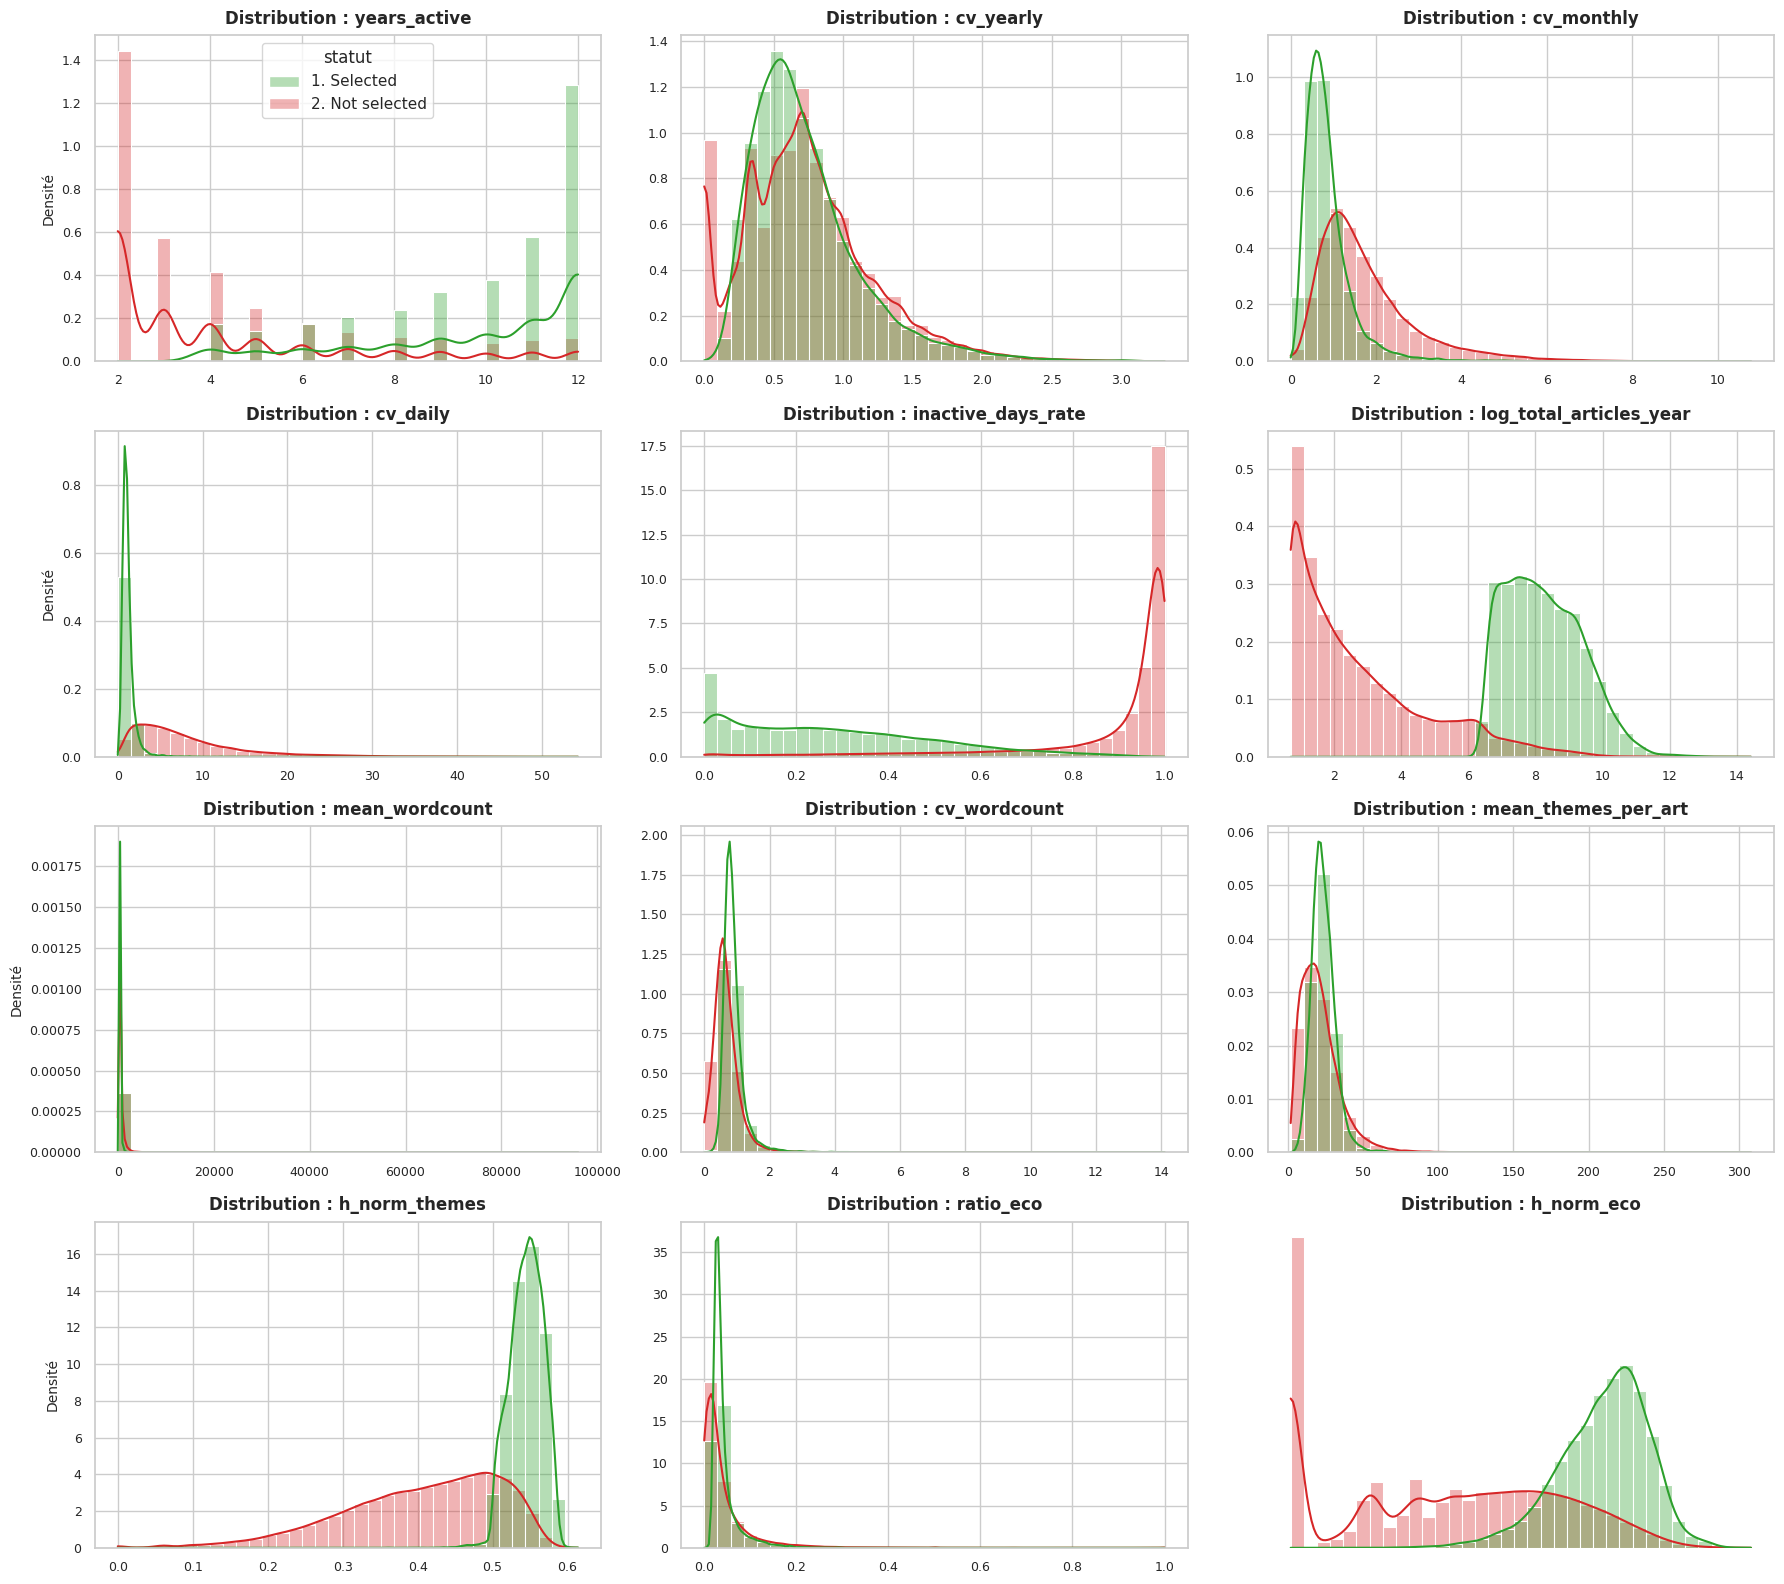

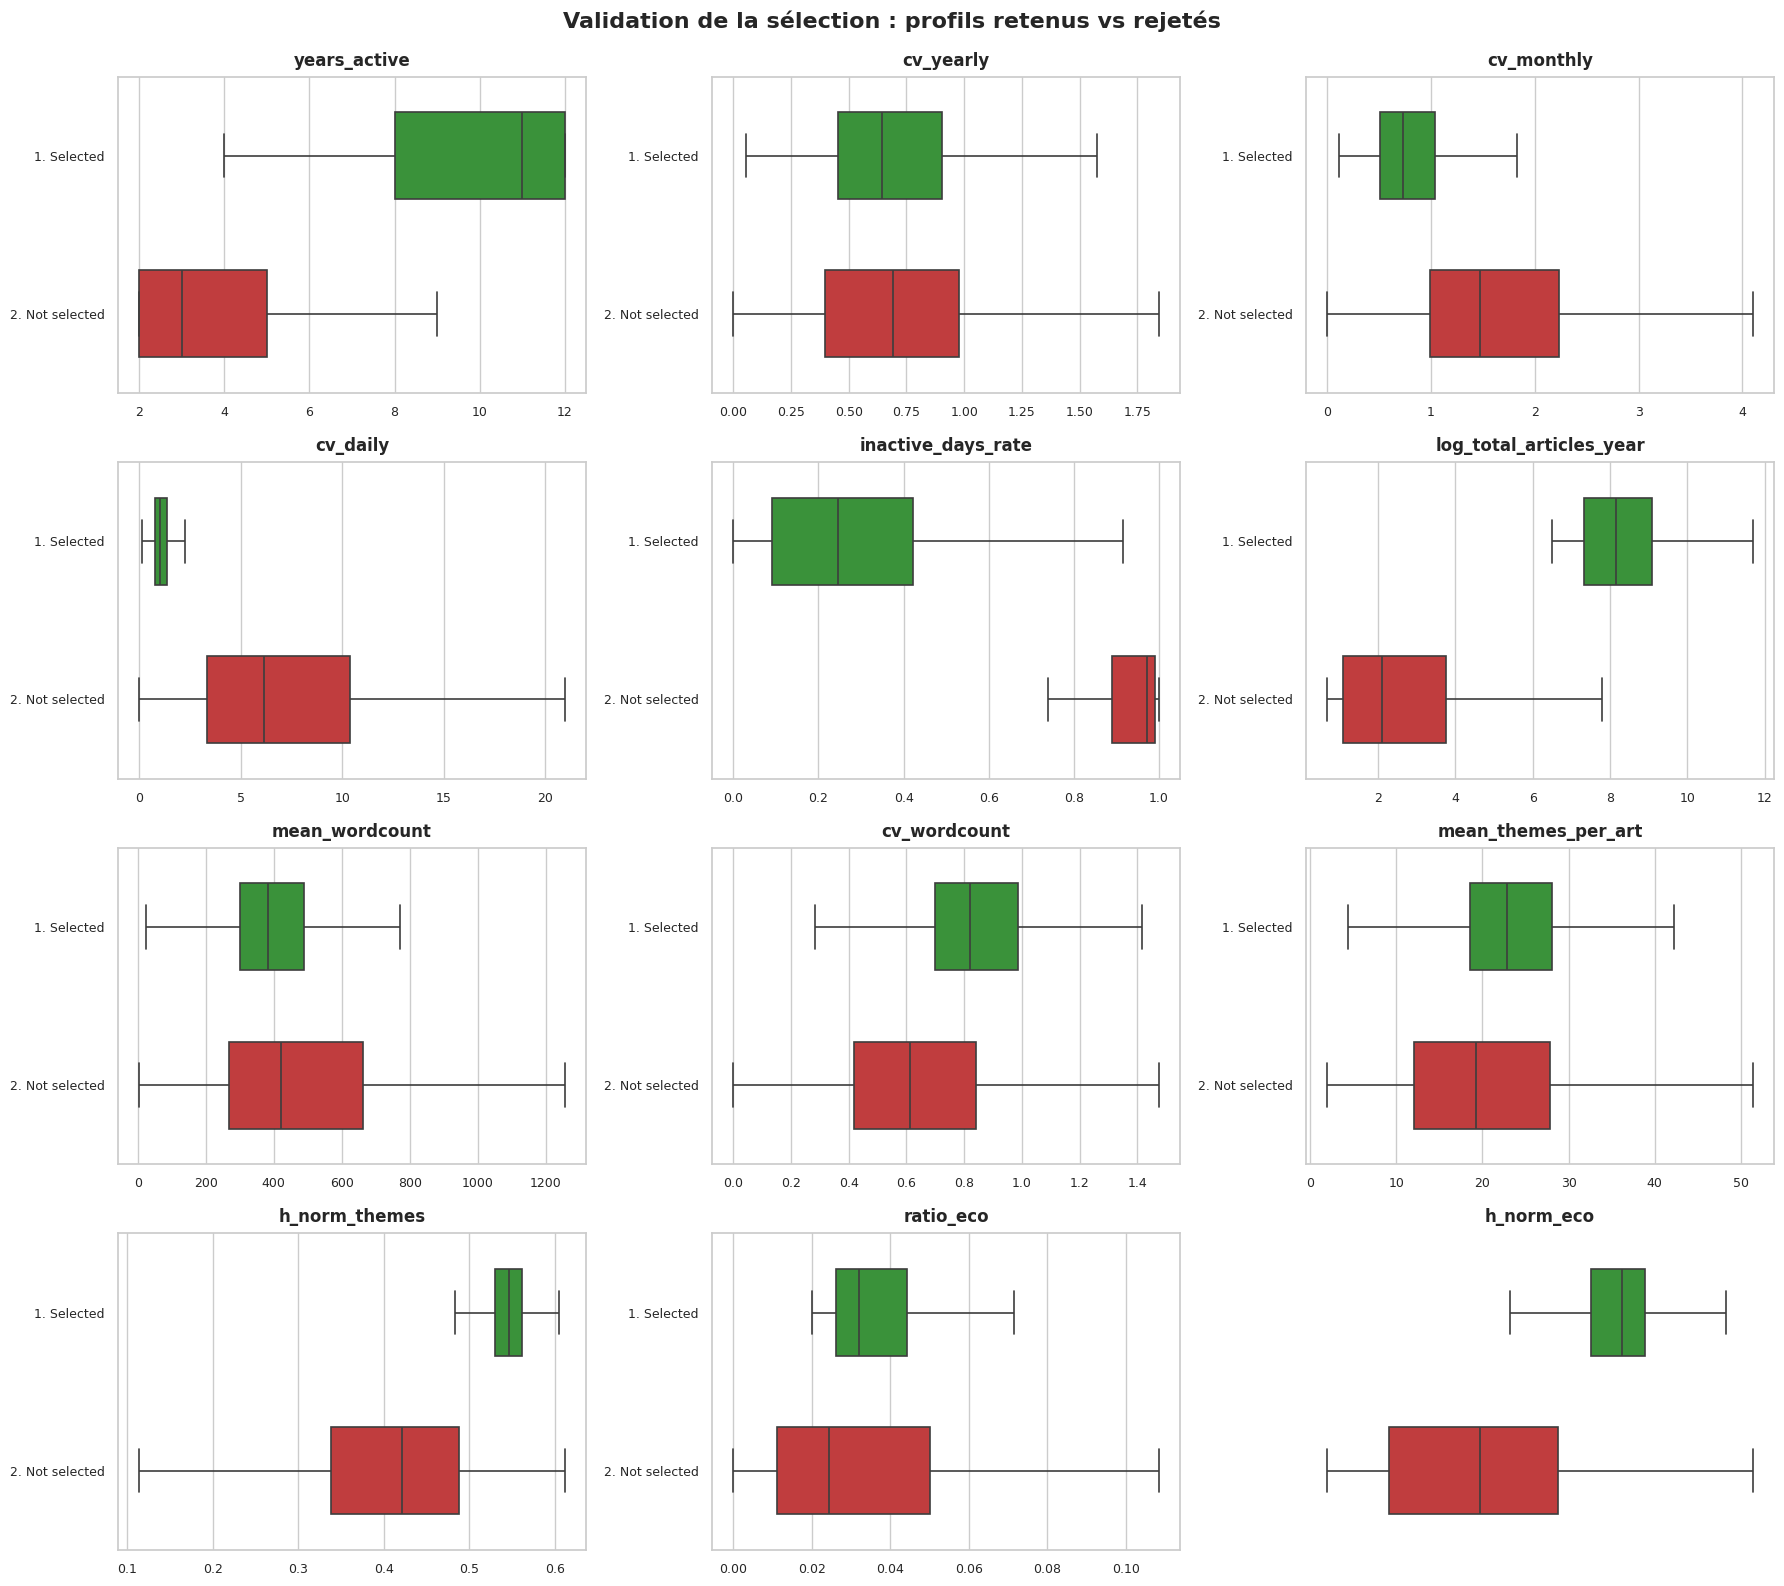

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"

features_to_plot = [
    "years_active",
    "cv_yearly",
    "cv_monthly",
    "cv_daily",
    "inactive_days_rate",
    "log_total_articles_year",
    "mean_wordcount",
    "cv_wordcount",
    "mean_themes_per_art",
    "h_norm_themes",
    "ratio_eco",
    "h_norm_eco",
]


def plot_comparison(df_selected, df_rejected, kind="hist"):
    df_selected = df_selected.copy().assign(statut="1. Selected")
    df_rejected = df_rejected.copy().assign(statut="2. Not selected")
    df_plot = pd.concat([df_selected, df_rejected], ignore_index=True)

    fig, axes = plt.subplots(4, 3, figsize=(18, 16))
    axes = axes.flatten()

    for i, col in enumerate(features_to_plot):
        ax = axes[i]
        if col not in df_plot.columns:
            continue

        if kind == "hist":
            sns.histplot(
                data=df_plot,
                x=col,
                hue="statut",
                stat="density",
                common_norm=False,
                kde=True,
                bins=35,
                alpha=0.35,
                palette={"1. Selected": "#2ca02c", "2. Not selected": "#d62728"},
                ax=ax,
                legend=(i == 0),
            )
            ax.set_title(f"Distribution : {col}", fontsize=12, fontweight="bold", pad=8)
            ax.set_xlabel("")
            ax.set_ylabel("Densité" if i % 3 == 0 else "", fontsize=10)
        else:
            sns.boxplot(
                data=df_plot,
                x=col,
                y="statut",
                hue="statut",
                showfliers=False,
                width=0.55,
                linewidth=1.2,
                palette={"1. Selected": "#2ca02c", "2. Not selected": "#d62728"},
                ax=ax,
                legend=False,
            )
            ax.set_title(col, fontsize=12, fontweight="bold", pad=8)
            ax.set_xlabel("")
            ax.set_ylabel("")

        ax.tick_params(labelsize=9)

    axes[-1].axis("off")
    if kind == "hist":
        plt.tight_layout()
        plt.show()
    else:
        fig.suptitle(
            "Validation de la sélection : profils retenus vs rejetés",
            fontsize=16,
            fontweight="bold",
            y=0.99,
        )
        plt.tight_layout()
        plt.show()


print("⏳ Génération des visualisations de sélection...")
plot_comparison(df_propre, df_rejetes, kind="hist")
plot_comparison(df_propre, df_rejetes, kind="box")

In [50]:
df_propre.head()

,SourceCommonName_ID,is_wiki,years_active,cv_monthly,cv_yearly,inactive_days_rate,mean_wordcount,cv_wordcount,mean_themes_per_art,h_norm_themes,ratio_eco,log_total_articles_year,h_norm_eco,cv_daily,total_articles
0,81,1,12,0.41,0.37,0.00,622.07,1.58,24.04,0.57,0.05,13.63,0.47,0.54,"9,942,046.00"
1,34473,1,12,0.92,0.81,0.01,818.17,1.03,29.91,0.53,0.12,13.16,0.34,1.06,"6,208,211.00"
2,724,1,12,0.19,0.20,0.00,362.15,0.75,21.88,0.57,0.06,12.93,0.46,0.25,"4,957,871.00"
3,427,1,9,0.73,0.66,0.00,582.73,1.26,30.36,0.59,0.03,13.06,0.48,0.80,"4,236,616.00"
4,26651,1,12,0.96,0.89,0.14,195.63,0.50,15.45,0.53,0.03,12.68,0.36,1.03,"3,861,668.00"


#### 4.2.2. Filtering through url, type and source common name analysis 

In [15]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import glob
import re
import ssl
import urllib.error
import urllib.request
import warnings
from bs4 import BeautifulSoup, XMLParsedAsHTMLWarning
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 🔥 SILENCE LES AVERTISSEMENTS XML DE BEAUTIFULSOUP
warnings.filterwarnings("ignore", category=XMLParsedAsHTMLWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="bs4")

print(
    "⏳ [1/5] Sécurisation des colonnes et chargement des métadonnées"
    " Wikidata..."
)

# ==============================================================================
# 0. SÉCURITÉ : RÉINJECTION DE 'SourceCommonName' ET DES LABELS WIKIDATA
# ==============================================================================
if "SourceCommonName" not in df_propre.columns:
  if "src_df" in globals():
    df_propre = df_propre.merge(src_df, on="SourceCommonName_ID", how="left")
    df_propre["SourceCommonName"] = df_propre["SourceCommonName"].fillna(
        df_propre["SourceCommonName_ID"].astype(str)
    )
  else:
    raise ValueError(
        "Erreur : Le dataframe 'src_df' est introuvable pour traduire les"
        " IDs !"
    )

if "df_rejetes" in globals() and "SourceCommonName" not in df_rejetes.columns:
  if "src_df" in globals():
    df_rejetes = df_rejetes.merge(src_df, on="SourceCommonName_ID", how="left")
    df_rejetes["SourceCommonName"] = df_rejetes["SourceCommonName"].fillna(
        df_rejetes["SourceCommonName_ID"].astype(str)
    )

# Récupération des labels Wikidata (medialabel, typelabel) si absents de df_propre
if (
    "medialabel" not in df_propre.columns
    or "typelabel" not in df_propre.columns
):
  domain_files = glob.glob("data/domains/domains_*.parquet")
  df_labels_list = []
  for f in domain_files:
    df_tmp = pd.read_parquet(f, columns=["id", "medialabel", "typelabel"])
    df_tmp["id"] = (
        pd.to_numeric(df_tmp["id"], errors="coerce").fillna(-1).astype(int)
    )
    df_labels_list.append(df_tmp)

  if df_labels_list:
    df_all_labels = pd.concat(df_labels_list, ignore_index=True).drop_duplicates(
        subset=["id"]
    )
    df_propre["SourceCommonName_ID"] = (
        pd.to_numeric(df_propre["SourceCommonName_ID"], errors="coerce")
        .fillna(-1)
        .astype(int)
    )
    df_propre = df_propre.merge(
        df_all_labels,
        left_on="SourceCommonName_ID",
        right_on="id",
        how="left",
    )
    if "df_rejetes" in globals():
      df_rejetes["SourceCommonName_ID"] = (
          pd.to_numeric(df_rejetes["SourceCommonName_ID"], errors="coerce")
          .fillna(-1)
          .astype(int)
      )
      df_rejetes = df_rejetes.merge(
          df_all_labels,
          left_on="SourceCommonName_ID",
          right_on="id",
          how="left",
      )

# ==============================================================================
# ÉTAPE 1 : GUILLOTINE PRÉLIMINAIRE (EXCLUSIONS URL ET LABELS WIKIDATA)
# ==============================================================================
print(
    "⏳ [2/5] Exécution de la guillotine préliminaire (.edu, gaming, religion,"
    " etc.)..."
)

# --- 1. EXCLUSIONS SUR LES LABELS WIKIDATA (medialabel + typelabel) ---
EXCLUDED_LABEL_KEYWORDS = [
    # Éducation & Science pure
    "university",
    "college",
    "school",
    "high school",
    "student",
    "academic journal",
    "scientific journal",
    "peerreview",
    "proceedings",
    # Sport & Divertissement
    "sports",
    "sports news",
    "tabloid",
    "video",
    "gaming",
    "gamer",
    "game",
    "poker",
    "gambl",
    "play",
    "movie",
    "cinema",
    "film",
    "serie",
    "anime",
    "manga",
    "entertainment",
    "pop culture",
    "music",
    "celebrit",
    "motor",
    "autom",
    "moto",
    "drive",
    "glamour",
    "vogue",
    "trend",
    "fashion",
    "style",
    "gear",
    # Religion & Communautaire
    "church",
    "bible",
    "torah",
    "quran",
    "religion",
    "catholic",
    "christian",
    "baptist",
    "jewish",
    "islamic",
    "muslim",
    "hinduism",
    "monastery",
    "theolog",
    "lgbt",
    "gay",
    # Local & Formats spécifiques
    "municipal newsletter",
    "children's newspaper",
    "local newspaper",
    "fake news",
    "satire",
]
EXCLUSION_LABEL_PATTERN = "|".join(
    re.escape(kw) for kw in EXCLUDED_LABEL_KEYWORDS
)

# --- 2. EXCLUSIONS ENRICHIES SUR LE NOM DE DOMAINE (URL / Website) ---
# Intégration complète des thématiques Wikidata sans faux positifs
EXCLUDED_DOMAIN_PATTERNS = [
    # 1. Éducation, Étudiants & Science pure (Ajout de student, scientific, peer-review)
    r"\.edu$|university|college|school|highschool|student|academic|scientific|peer-?review|proceedings|^ij[a-z]{2,}\.org|journalof|sciedu|springer|ieee|sciencedirect",
    # 2. Religion & Communautaire (INÉDIT EN URL : indispensable pour les sites sans Wikidata !)
    r"church|bible|torah|quran|religion|catholic|christian|baptist|jewish|islamic|muslim|hinduism|monastery|theolog|lgbt|[-.]gay[-.]|^gay",
    # 3. Sport, Tabloïds & Généralités loisirs
    r"sports?|stadium|athletics|espn|nba|nfl|fifa|futebol|calcio|soccer|tabloid|entertainment|pop-?culture|celebrit|gossip|paparazzi",
    # 4. Gaming, Cinéma, Musique, Anime & Pop-Culture (Ajout de movie, cinema, film, anime, manga, music...)
    r"gaming|gamer|esports?|videojuego|playstation|nintendo|xbox|3djuegos|kotaku|ign\.|gamespot|3dmgame|crunchyroll|animenews|serienjunkies|brobible|filmfare|cineblitz|rocketnews24|movie|cinema|film|serie|anime|manga|comics|music",
    # 5. Mode, Luxe, Lifestyle & Féminin (Ajout de style, trend, glamour, beauty, gear...)
    r"vogue|vanityfair|gq\.|esquire|marieclaire|cosmopolitan|fashion|brides\.|madmoizelle|glamour|beaut|stylecaster|woman|women|madame|townandcountry|madamenoire|elle\.|lifestyle|haute-?couture|wedding|bridal|trend|gear",
    # 6. Automobile, Moto & Mécanique loisirs (Ajout de motor, moto, autom sécurisés)
    r"autoblog|autoevolution|caranddriver|carbuzz|carscoops|jalopnik|motor1|motortrend|topgear|quattroruote|wheels24|roadandtrack|zr\.ru|supercar|motoring|automag|carmag|[-.]moto[-.]|^moto",
    # 7. Crypto, Paris, Casinos & Jeux d'argent (Ajout de gambl, poker, play)
    r"crypto|bitcoin|casino|betting|poker|apuestas|odds|gambling|gambl|token|nft[-.]|[-.]nft|lotto|lottery|[-.]play[-.]|playonline",
    # 8. Astrologie & Horoscope
    r"horoscope|astrolog|zodiac|tarot",
    # 9. Coupons, Promo & E-commerce
    r"coupon|promocod|discount|[-.]deal|deal[-.]|dailydeal|hotdeal|shoponline|boutique",
    # 10. Communiqués de presse (PR & Newswires - Ratio éco artificiel)
    r"prnewswire|businesswire|globenewswire|einpresswire|einnews|prlog|prweb|openpr|accesswire|targetednews|pressreleasepoint|newswire|press-?release",
    # 11. Forums, Satire, Fake news & OVNIs
    r"godlikeproductions|lunaticoutpost|fark\.|slashdot|wykop|quora|reddit|satire|fake-?news|newsletter|xbiz",
    # 🔥 TOUCHE FINALE : Purge des micro-parasites résiduels (Féminin, Gadgets, Blogs, Gossip, VIP)
    r"woman|women|weib|femme|gearjunkie|slashgear|ubergizmo|tweaktown|wonkette|twitchy|wordpress\.|typepad\.|vip\.de|viply|xbiz"
]
EXCLUSION_DOMAIN_PATTERN = "|".join(EXCLUDED_DOMAIN_PATTERNS)

# A. Application du filtre sur les URL (Domaines)
mask_url = (
    df_propre["SourceCommonName"]
    .astype(str)
    .str.lower()
    .str.contains(EXCLUSION_DOMAIN_PATTERN, regex=True, na=False)
)

# B. Application du filtre sur le texte Wikidata (medialabel + typelabel)
text_wiki_propre = (
    df_propre["medialabel"].fillna("").astype(str)
    + " "
    + df_propre["typelabel"].fillna("").astype(str)
).str.lower()
mask_wiki = text_wiki_propre.str.contains(
    EXCLUSION_LABEL_PATTERN, regex=True, na=False
)

# C. Élimination immédiate
mask_exclusion_preliminaire = mask_url | mask_wiki
df_exclus_prelim = df_propre[mask_exclusion_preliminaire].copy()
df_propre = df_propre[~mask_exclusion_preliminaire].copy()

if "df_rejetes" in globals():
  df_rejetes = pd.concat(
      [df_rejetes, df_exclus_prelim], ignore_index=True
  ).drop_duplicates(subset=["SourceCommonName_ID"])
else:
  df_rejetes = df_exclus_prelim.copy()

print(
    f"❌ Sources éliminées en préliminaire (URL ou Wikidata) :"
    f" {len(df_exclus_prelim):,}"
)
print(f"✔ Échantillon propre envoyé au scraper HTML : {len(df_propre):,}\n")

# ==============================================================================
# ÉTAPE 2 : SCRAPING HTML POLYGLOTTE (SUR LES RESCAPÉS UNIQUEMENT)
# ==============================================================================
print("⏳ [3/5] Lancement du crawler HTML V7 sur 25 threads...")

domaines_a_tester = (
    df_propre[["SourceCommonName_ID", "SourceCommonName"]]
    .dropna(subset=["SourceCommonName"])
    .drop_duplicates(subset=["SourceCommonName_ID"])
    .to_dict(orient="records")
)

POSITIVE_NEWS_KEYWORDS = [
    # Anglais
    "news",
    "journalism",
    "newspaper",
    "daily",
    "opinion",
    "editorials",
    "headlines",
    "community",
    "events",
    "public broadcaster",
    "reporting",
    "journal",
    "gazette",
    "herald",
    "chronicle",
    "examiner",
    "tribune",
    "bulletin",
    "dispatch",
    "courier",
    "observer",
    "telegram",
    "standard",
    "times",
    "post",
    "independent",
    "radio",
    "podcast",
    "broadcast",
    "press",
    "politics",
    "economy",
    "business",
    "finance",
    "financial",
    "investing",
    "stock market",
    "weather",
    "current affairs",
    # Français / Espagnol / Portugais / Italien / Catalan
    "actu",
    "actualité",
    "actualités",
    "info",
    "information",
    "quotidien",
    "société",
    "politique",
    "économie",
    "bourse",
    "presse",
    "direct",
    "replay",
    "actualidad",
    "noticias",
    "notícias",
    "diario",
    "diário",
    "periodico",
    "periódico",
    "economia",
    "finanzas",
    "finanças",
    "sociedad",
    "sociedade",
    "última hora",
    "giornale",
    "notizie",
    "cronaca",
    "attualità",
    "quotidiano",
    "informazione",
    "stampa",
    # Allemand / Néerlandais
    "nachrichten",
    "zeitung",
    "wirtschaft",
    "politik",
    "nieuws",
    "krant",
    "politiek",
    "economie",
    "beurs",
    "actueel",
    "aktuell",
    "aktuelles",
    "dagblad",
    "rundschau",
    "blatt",
    # Scandinave
    "nyheder",
    "nyheter",
    "nytt",
    "nyt",
    "avisen",
    "avis",
    "regionavis",
    "lokal",
    "lokale",
    "regionale",
    "innenriks",
    "utenriks",
    "nyhetssajt",
    "nyhedssite",
    "dagbladet",
    "aftenblad",
    "tidende",
    "folkeblad",
    "samfunn",
    # Europe Centrale & Balkans (Tchèque, Serbe latin "vesti" !)
    "hírek",
    "hírportál",
    "napilap",
    "belföld",
    "külföld",
    "aktualitások",
    "friss",
    "știri",
    "stiri",
    "ziar",
    "actualitate",
    "cotidian",
    "zprávy",
    "zpravodajství",
    "zpravodajský",
    "publicistika",
    "počasí",
    "správy",
    "deník",
    "denik",
    "wiadomości",
    "informacje",
    "gazeta",
    "dziennik",
    "polityka",
    "gospodarka",
    "wydarzenia",
    "novini",
    "novosti",
    "vijesti",
    "vesti",
    "dnevnik",
    "jutarnji",
    "eidiseis",
    "επικαιρότητα",
    "ειδήσεις",
    # Asie & Russe/Cyrillique
    "berita",
    "kabar",
    "harian",
    "aktual",
    "nasional",
    "новости",
    "газета",
    "политика",
    "экономика",
    "новое",
    "вести",
    "новини",
    "політика",
    "економіка",
    "вісті",
]

STRICT_KILL_KEYWORDS = {
    "Gaming & Jeux Vidéo": [
        "videojuegos",
        "nintendo",
        "playstation",
        "xbox",
        "mmorpg",
        "cheat codes",
        "gaming console",
        "pc gaming",
        "steam",
        "gry online",
        "darmowe gry",
        "jogos online",
        "spiele online",
    ],
    "Académique Pur": [
        "peer-reviewed",
        "scientific journal",
        "proceedings of",
        "clinical trials",
        "academic journal",
    ],
    "Shopping & Promo": [
        "coupon code",
        "promo code",
        "discount codes",
        "shop online boutique",
        "e-commerce store",
        "kody rabatowe",
        "cupones descuento",
    ],
}

SOFT_KILL_KEYWORDS = [
    # Sport / Tech / Gaming
    "gaming",
    "gamer",
    "esports",
    "tech reviews",
    "gadget",
    "hardware",
    "sports",
    "deportes",
    "sport",
    "futebol",
    "calcio",
    "pilka",
    "tenis",
    # Gossip / Astrologie / People / Mode
    "horoscope",
    "astrology",
    "astrologie",
    "tarot",
    "zodiac",
    "horoskop",
    "astrologia",
    "celebrity news",
    "celebrity gossip",
    "gossip",
    "paparazzi",
    "fashion",
    "haute couture",
    "famosos",
    "promis",
    "gwiazdy",
    "celebridades",
    # Cuisine / Voyage / Lifestyle
    "recipes",
    "recetas",
    "recettes",
    "cooking",
    "cuisine",
    "foodie",
    "przepisy",
    "kuchnia",
    "style",
    "entertainment",
    "culture",
    "travel",
    "voyage",
    "reisen",
    "podróże",
    "magazine",
    "decor",
]

ssl_ctx = ssl.create_default_context()
ssl_ctx.check_hostname = False
ssl_ctx.verify_mode = ssl.CERT_NONE


def inspect_homepage(row):
  domain = str(row["SourceCommonName"]).strip()
  src_id = row["SourceCommonName_ID"]
  url = f"https://{domain}"
  headers = {
      "User-Agent": (
          "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML,"
          " like Gecko) Chrome/120.0.0.0 Safari/537.36"
      ),
      "Accept-Language": "en-US,en;q=0.9,fr;q=0.8,es;q=0.7,de;q=0.6,pl;q=0.5",
  }

  try:
    req = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(req, timeout=4, context=ssl_ctx) as response:
      html = response.read(100000).decode("utf-8", errors="ignore")

    soup = BeautifulSoup(html, "html.parser")
    html_tag = soup.find("html")
    detected_lang = (
        html_tag.get("lang", "")[:2].lower()
        if html_tag and html_tag.get("lang")
        else "inconnu"
    )

    title = soup.title.string if soup.title else ""
    meta_desc = soup.find(
        "meta", attrs={"name": re.compile(r"^description$", re.I)}
    )
    og_desc = soup.find(
        "meta", attrs={"property": re.compile(r"^og:description$", re.I)}
    )

    text_to_check = (
        f"{title} {meta_desc['content'] if meta_desc and 'content' in meta_desc.attrs else ''} {og_desc['content'] if og_desc and 'content' in og_desc.attrs else ''}"
    ).lower()

    # 1. Guillotine absolue
    for cat, mots in STRICT_KILL_KEYWORDS.items():
      for mot in mots:
        if re.search(r"\b" + re.escape(mot) + r"\b", text_to_check):
          return {
              "SourceCommonName_ID": src_id,
              "domain": domain,
              "lang": detected_lang,
              "status": "❌ Exclus",
              "motif": f"Guillotine Absolue {cat} ('{mot}')",
              "extrait_meta": text_to_check[:110].strip(),
          }

    # 2. Bouclier News Mondial
    has_news_keywords = any(
        re.search(r"\b" + re.escape(pos) + r"\b", text_to_check)
        for pos in POSITIVE_NEWS_KEYWORDS
    )

    # 3. Arbitrage Rubriques / Loisirs / Sports / Astrologie
    for mot_doux in SOFT_KILL_KEYWORDS:
      if re.search(r"\b" + re.escape(mot_doux) + r"\b", text_to_check):
        if has_news_keywords:
          return {
              "SourceCommonName_ID": src_id,
              "domain": domain,
              "lang": detected_lang,
              "status": "✔ Presse Légitime",
              "motif": f"Sauvé par Contexte News ('{mot_doux}')",
              "extrait_meta": text_to_check[:110].strip(),
          }
        else:
          return {
              "SourceCommonName_ID": src_id,
              "domain": domain,
              "lang": detected_lang,
              "status": "❌ Exclus",
              "motif": f"Spécialisé Loisirs/Sport sans actu ('{mot_doux}')",
              "extrait_meta": text_to_check[:110].strip(),
          }

    return {
        "SourceCommonName_ID": src_id,
        "domain": domain,
        "lang": detected_lang,
        "status": "✔ Presse Légitime",
        "motif": "OK (Standard)",
        "extrait_meta": text_to_check[:110].strip(),
    }

  except Exception:
    return {
        "SourceCommonName_ID": src_id,
        "domain": domain,
        "lang": "n/a",
        "status": "✔ Presse Légitime",
        "motif": "OK (Inaccessible web - Sauvé par statistiques)",
        "extrait_meta": "",
    }


results = []
with ThreadPoolExecutor(max_workers=25) as executor:
  futures = {
      executor.submit(inspect_homepage, row): row for row in domaines_a_tester
  }
  for i, future in enumerate(as_completed(futures), 1):
    results.append(future.result())
    if i % 250 == 0 or i == len(domaines_a_tester):
      print(
          f"   ➔ Progression : {i:,} / {len(domaines_a_tester):,} sites"
          " vérifiés..."
      )

df_scrape_results = pd.DataFrame(results)

# ==============================================================================
# ÉTAPE 3 : MISE À JOUR FINALE DES TABLEAUX DE SÉLECTION
# ==============================================================================
print("\n⏳ [4/5] Basculement des exclus HTML vers df_rejetes...")

ids_exclus_html = set(
    df_scrape_results[df_scrape_results["status"] == "❌ Exclus"][
        "SourceCommonName_ID"
    ]
)

df_exclus_web = df_propre[
    df_propre["SourceCommonName_ID"].isin(ids_exclus_html)
].copy()
df_propre = df_propre[
    ~df_propre["SourceCommonName_ID"].isin(ids_exclus_html)
].copy()

if "df_rejetes" in globals():
  df_rejetes = pd.concat(
      [df_rejetes, df_exclus_web], ignore_index=True
  ).drop_duplicates(subset=["SourceCommonName_ID"])
else:
  df_rejetes = df_exclus_web.copy()

print("\n📊 BILAN DU NETTOYAGE HTML DES PAGES D'ACCUEIL :")
display(
    df_scrape_results["status"]
    .value_counts()
    .rename("Nombre de domaines")
    .to_frame()
)

if len(df_exclus_web) > 0:
  print(
      f"\n🚫 Exemples de sites éliminés grâce au contenu HTML ({len(df_exclus_web):,} sites) :"
  )
  df_diag = df_scrape_results[df_scrape_results["status"] == "❌ Exclus"][
      ["domain", "lang", "motif", "extrait_meta"]
  ]
  display(df_diag.head(25).style.set_properties(**{"text-align": "left"}))

# ==============================================================================
# ÉTAPE 4 : EXPORT ULTIME DU GOLD STANDARD
# ==============================================================================
print("⏳ [5/5] Exportation définitive du Gold Standard...")

output_parquet = "echantillon_medias_economiques_propre.parquet"
output_csv = "echantillon_medias_economiques_propre.csv"
output_txt_ids = "liste_ids_retenus.txt"
output_txt_domaines = "liste_sites_retenus.txt"

df_propre.to_parquet(output_parquet, index=False)
df_propre.to_csv(output_csv, index=False, encoding="utf-8")

liste_ids_ultime = df_propre["SourceCommonName_ID"].dropna().unique()
with open(output_txt_ids, "w", encoding="utf-8") as f:
  f.write("\n".join(liste_ids_ultime.astype(str)))

if "SourceCommonName" in df_propre.columns:
  liste_domaines_ultime = (
      df_propre["SourceCommonName"].dropna().astype(str).str.lower().unique()
  )
  with open(output_txt_domaines, "w", encoding="utf-8") as f:
    f.write("\n".join(sorted(liste_domaines_ultime)))

print("\n✔ TERMINÉ ! Pipeline blindé : Guillotine Amont + Bouclier HTML V7.")
print(f"  ↳ Parquet final   : {output_parquet} ({len(df_propre):,} médias)")
print(f"  ↳ Fichier pour N2 : {output_txt_ids} ({len(liste_ids_ultime):,} IDs)")

⏳ [1/5] Sécurisation des colonnes et chargement des métadonnées Wikidata...
⏳ [2/5] Exécution de la guillotine préliminaire (.edu, gaming, religion, etc.)...
❌ Sources éliminées en préliminaire (URL ou Wikidata) : 224
✔ Échantillon propre envoyé au scraper HTML : 13,443

⏳ [3/5] Lancement du crawler HTML V7 sur 25 threads...
   ➔ Progression : 250 / 13,443 sites vérifiés...
   ➔ Progression : 500 / 13,443 sites vérifiés...
   ➔ Progression : 750 / 13,443 sites vérifiés...
   ➔ Progression : 1,000 / 13,443 sites vérifiés...
   ➔ Progression : 1,250 / 13,443 sites vérifiés...
   ➔ Progression : 1,500 / 13,443 sites vérifiés...
   ➔ Progression : 1,750 / 13,443 sites vérifiés...
   ➔ Progression : 2,000 / 13,443 sites vérifiés...
   ➔ Progression : 2,250 / 13,443 sites vérifiés...
   ➔ Progression : 2,500 / 13,443 sites vérifiés...
   ➔ Progression : 2,750 / 13,443 sites vérifiés...
   ➔ Progression : 3,000 / 13,443 sites vérifiés...
   ➔ Progression : 3,250 / 13,443 sites vérifiés...
   

,Nombre de domaines
status,
✔ Presse Légitime,13334
❌ Exclus,109



🚫 Exemples de sites éliminés grâce au contenu HTML (109 sites) :


,domain,lang,motif,extrait_meta
3,indiatimes.com,en,Spécialisé Loisirs/Sport sans actu ('fashion'),"indiatimes: latest in lifestyle, health, fashion, and wellness indiatimes is your destination when it comes to"
1596,diena.lv,lv,Spécialisé Loisirs/Sport sans actu ('sports'),"diena - lielākais nacionālais laikraksts diena — latvijas ziņas, kultūra, sports diena — latvijas ziņas, kultū"
2155,panchjanya.com,hi,Spécialisé Loisirs/Sport sans actu ('magazine'),"panchjanya weekly magazine in hindi, समाचार विश्लेषण, बात भारत की पाञ्चजन्य में पढ़ें समाचार और सटीक विश्लेषण,"
2668,4players.de,de,Guillotine Absolue Gaming & Jeux Vidéo ('xbox'),"4p - das spielemagazin - 4p.de 4p (ehemals 4players) bringt euch aktuelle gaming-news, spieletests, previews u"
2852,isabadell.cat,ca,Spécialisé Loisirs/Sport sans actu ('esports'),"isabadell.cat isabadell és el diari digital de referència a sabadell. notícies locals, política, societat, cul"
3396,pinkvilla.com,en,Spécialisé Loisirs/Sport sans actu ('fashion'),"pinkvilla: latest entertainment , box office collections, movie reviews, latest videos, korean, fashion & life"
3417,mali-web.org,fr,Spécialisé Loisirs/Sport sans actu ('voyage'),mali web : votre guide touristique au cœur du mali découvrez les merveilles du mali à travers des articles ins
4538,mashable.com,en,Spécialisé Loisirs/Sport sans actu ('entertainment'),"mashable mashable is a global, multi-platform media and entertainment company. mashable is a global, multi-pla"
4649,tbo.com,en,Spécialisé Loisirs/Sport sans actu ('travel'),leading global travel distribution platform - tbo.com tbo is an online booking travel portal for travel agent
4767,balkanweb.com,sq,Spécialisé Loisirs/Sport sans actu ('sport'),"balkanweb.com – news24 – kryesore | lajm i fundit mbulon me lajme të gjithë kategoritë: shqiperi, politike,akt"


⏳ [5/5] Exportation définitive du Gold Standard...

✔ TERMINÉ ! Pipeline blindé : Guillotine Amont + Bouclier HTML V7.
  ↳ Parquet final   : echantillon_medias_economiques_propre.parquet (13,334 médias)
  ↳ Fichier pour N2 : liste_ids_retenus.txt (13,334 IDs)


In [61]:
from IPython.display import display
import pandas as pd

print("⏳ Création du diagnostic trié par volume d'articles...")

# 1. On filtre les résultats du scraper pour ne garder que les exclus
df_diag = df_scrape_results[df_scrape_results["status"] == "❌ Exclus"].copy()

# 2. On enrichit avec le nombre d'articles en faisant une jointure sur l'ID
if "total_articles" not in df_diag.columns:
  df_diag = df_diag.merge(
      df_exclus_web[["SourceCommonName_ID", "total_articles"]],
      on="SourceCommonName_ID",
      how="left",
  )

# 3. Sélection des colonnes et tri par ordre décroissant de volume
cols_visu = ["domain", "lang", "total_articles", "motif", "extrait_meta"]
df_diag_sorted = df_diag[cols_visu].sort_values(
    by="total_articles", ascending=False, ignore_index=True
)

print(
    f"🚫 Top 50 des {len(df_diag_sorted):,} sites éliminés par le HTML,"
    " classés par volume d'articles :\n"
    + "=" * 90
)

# 4. Affichage propre (avec formatage des milliers pour les articles)
with pd.option_context("display.max_rows", 50, "display.max_colwidth", 80):
  display(
      df_diag_sorted.head(50)
      .style.format({"total_articles": "{:,.0f}"})
      .set_properties(**{"text-align": "left", "font-size": "11px"})
      .set_properties(
          subset=["domain", "total_articles"], **{"font-weight": "bold"}
      )
  )

⏳ Création du diagnostic trié par volume d'articles...
🚫 Top 50 des 117 sites éliminés par le HTML, classés par volume d'articles :


,domain,lang,total_articles,motif,extrait_meta
0,indiatimes.com,en,"4,957,871",Spécialisé Loisirs/Sport sans actu ('fashion'),"indiatimes: latest in lifestyle, health, fashion, and wellness indiatimes is your destination when it comes to"
1,pinkvilla.com,en,"229,876",Spécialisé Loisirs/Sport sans actu ('fashion'),"pinkvilla: latest entertainment , box office collections, movie reviews, latest videos, korean, fashion & life"
2,mashable.com,en,"106,795",Spécialisé Loisirs/Sport sans actu ('entertainment'),"mashable mashable is a global, multi-platform media and entertainment company. mashable is a global, multi-pla"
3,tbo.com,en,"104,051",Spécialisé Loisirs/Sport sans actu ('travel'),leading global travel distribution platform - tbo.com tbo is an online booking travel portal for travel agent
4,balkanweb.com,sq,"96,868",Spécialisé Loisirs/Sport sans actu ('sport'),"balkanweb.com – news24 – kryesore | lajm i fundit mbulon me lajme të gjithë kategoritë: shqiperi, politike,akt"
5,hypebeast.com,en,"94,776",Spécialisé Loisirs/Sport sans actu ('fashion'),"hypebeast - fashion, sneakers, art, design & culture hypebeast covers men's contemporary fashion and culture,"
6,pudelek.pl,pl,"87,187",Spécialisé Loisirs/Sport sans actu ('gwiazdy'),"pudelek.pl - plotki, gwiazdy, sensacja tylko świeże plotki ze świata polskich i zagranicznych celebrytów. najn"
7,brigitte.de,de,"86,919",Spécialisé Loisirs/Sport sans actu ('horoskop'),"brigitte: dein leben. dein weg. | brigitte.de brigitte inspiriert deinen alltag: von karriere bis horoskop, vo"
8,lavocedeltrentino.it,it,"72,208",Spécialisé Loisirs/Sport sans actu ('style'),home | la voce del trentino [tps_header][/tps_header][tps_title][/tps_title][tps_footer][/tps_footer][tps_sta
9,ma.hu,inconnu,"71,690",Spécialisé Loisirs/Sport sans actu ('sport'),"hrek - www.ma.hu hrek, belfld, klfld, gazdasg, bulvr, sport, informatika, kultra, letmd, tudomny, zene, sznhz,"


In [16]:
from IPython.display import display
import pandas as pd

print("⏳ Génération d'un échantillon aléatoire de 1000 domaines...")

# 1. Sécurité : on s'assure d'avoir la colonne des noms de domaine
if "SourceCommonName" not in df_propre.columns and "src_df" in globals():
  df_propre = df_propre.merge(src_df, on="SourceCommonName_ID", how="left")
  df_propre["SourceCommonName"] = df_propre["SourceCommonName"].fillna(
      df_propre["SourceCommonName_ID"].astype(str)
  )

# 2. Échantillonnage aléatoire (ou maximum disponible si moins de 1000 lignes)
n_samples = min(15000, len(df_propre))
df_sample = df_propre.sample(
    n=n_samples, random_state=42
)  # random_state fixe pour pouvoir reproduire le même tirage si besoin

# 3. Sélection des colonnes utiles pour votre audit visuel
cols_visu = [
    c
    for c in ["SourceCommonName", "Origine", "total_articles", "ratio_eco"]
    if c in df_sample.columns
]
df_visu = df_sample[cols_visu].sort_values(
    by="SourceCommonName", ignore_index=True
)

# 4. Affichage complet des 1000 lignes dans le Notebook
print(f"✔ Voici {len(df_visu):,} domaines tirés au hasard (classés par ordre alphabétique) :\n" + "="*80)

# with pd.option_context("display.max_rows", 10000, "display.max_columns", 10):
#   display(
#       df_visu.style.set_properties(
#           **{"text-align": "left", "font-size": "11px", "padding": "2px 8px"}
#       ).set_properties(subset=["SourceCommonName"], **{"font-weight": "bold"})
#   )

# 5. Sauvegarde bonus dans un fichier texte pour une lecture fluide dans Notepad / VS Code
output_sample = "echantillon_1000_domaines_aleatoires.txt"
with open(output_sample, "w", encoding="utf-8") as f:
  f.write("\n".join(df_visu["SourceCommonName"].astype(str).values))

print(f"\n✔ Échantillon également sauvegardé dans le fichier : '{output_sample}'")

⏳ Génération d'un échantillon aléatoire de 1000 domaines...
✔ Voici 13,334 domaines tirés au hasard (classés par ordre alphabétique) :

✔ Échantillon également sauvegardé dans le fichier : 'echantillon_1000_domaines_aleatoires.txt'
